# **Transfer Learning y Fine-Tuning sobre CIFAR-10**

---
# **1. Dataset**

## **Librerías y configuración global**

In [1]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models

SEED = 123


def fijar_semilla(seed=SEED):
    """Fija las semillas de Python, NumPy y PyTorch para que los experimentos sean reproducibles."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


fijar_semilla()

# Se utiliza la GPU de Apple (MPS) y, si no está disponible, la CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Versión de PyTorch: {torch.__version__}")
print(f"Versión de torchvision: {torchvision.__version__}")
print(f"Dispositivo: {DEVICE}")
print(f"Semilla: {SEED}")

Versión de PyTorch: 2.14.0
Versión de torchvision: 0.29.0
Dispositivo: mps
Semilla: 123


## **Carga de CIFAR-10**

In [2]:
DATA_DIR = "data"

train = datasets.CIFAR10(root=DATA_DIR, train=True, download=True)
test = datasets.CIFAR10(root=DATA_DIR, train=False, download=True)

CLASES = train.classes

print(f"Imágenes de entrenamiento: {len(train)}")
print(f"Imágenes de test: {len(test)}")
print(f"Número de clases: {len(CLASES)}")
print(f"Clases: {CLASES}")

100%|██████████| 170M/170M [45:50<00:00, 62.0kB/s]   


Imágenes de entrenamiento: 50000
Imágenes de test: 10000
Número de clases: 10
Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


CIFAR-10 es un dataset público de clasificación multiclase compuesto por 60,000 imágenes a color de 32x32 píxeles, distribuidas en 10 categorías: avión, automóvil, pájaro, gato, venado, perro, rana, caballo, barco y camión. Viene dividido en 50,000 imágenes de entrenamiento y 10,000 de test, y cada imagen pertenece a una sola clase, por lo que el problema consiste en asignar la etiqueta correcta a partir de los píxeles.

Se carga mediante `torchvision.datasets.CIFAR10`, donde el parámetro `train` indica si se obtiene el conjunto de entrenamiento o el de test. 

---
# **2. Exploración y preparación de los datos**

**¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Las clases están balanceadas?**

En total, el dataset está compuesto por 60,000 observaciones, de las cuales 50,000 corresponden al conjunto de entrenamiento y 10,000 al conjunto de test. Asimismo, se identifican 10 categorías: airplane, automobile, bird, cat, deer, dog, frog, horse, ship y truck.

En cuanto al balance, todas las categorías están representadas con la misma cantidad de imágenes tanto en entrenamiento como en test, ya que cada clase cuenta con 5,000 imágenes en el primero y 1,000 en el segundo, es decir, un 10 % del total en ambos casos. Esto quiere decir que más adelante, al evaluar los modelos, la accuracy puede utilizarse como una métrica confiable, pues al no existir desbalance el total de aciertos no se ve favorecido por predecir con mayor frecuencia alguna clase dominante. Por ejemplo, un modelo que eligiera siempre la misma categoría obtendría únicamente un 10 % de accuracy, por lo que este valor funciona como la línea base contra la cual se pueden comparar los modelos. No obstante, que los datos estén balanceados no garantiza que el modelo aprenda todas las clases por igual, por lo que la accuracy se complementará con precision, recall y F1-score en su versión macro.

In [3]:
print(f"Observaciones en entrenamiento: {len(train)}")
print(f"Observaciones en test: {len(test)}")
print(f"Observaciones totales: {len(train) + len(test)}")
print(f"Número de clases: {len(CLASES)}")

Observaciones en entrenamiento: 50000
Observaciones en test: 10000
Observaciones totales: 60000
Número de clases: 10


In [4]:
etiquetas_train = pd.Series(train.targets).map(lambda i: CLASES[i])
etiquetas_test = pd.Series(test.targets).map(lambda i: CLASES[i])

# Se calcula la cantidad y el porcentaje de imágenes por clase en cada conjunto
distribucion = pd.DataFrame({
    "Imágenes (train)": etiquetas_train.value_counts(),
    "% (train)": etiquetas_train.value_counts(normalize=True).mul(100).round(2),
    "Imágenes (test)": etiquetas_test.value_counts(),
    "% (test)": etiquetas_test.value_counts(normalize=True).mul(100).round(2),
}).reindex(CLASES)

distribucion

,Imágenes (train),% (train),Imágenes (test),% (test)
airplane,5000,10.0,1000,10.0
automobile,5000,10.0,1000,10.0
bird,5000,10.0,1000,10.0
cat,5000,10.0,1000,10.0
deer,5000,10.0,1000,10.0
dog,5000,10.0,1000,10.0
frog,5000,10.0,1000,10.0
horse,5000,10.0,1000,10.0
ship,5000,10.0,1000,10.0
truck,5000,10.0,1000,10.0


**¿Cuál es la resolución y el número de canales de las imágenes? Calcule la media y desviación estándar por canal del conjunto de entrenamiento y compárelas con las estadísticas de normalización de ImageNet.**

Las imágenes tienen una resolución relativamente baja de 32x32 píxeles y 3 canales, por lo que se trabajará con imágenes a color en formato RGB, donde cada canal toma valores enteros de 0 a 255.

Tras escalar los píxeles al intervalo de 0 a 1, se obtuvo una media de 0.4914, 0.4822 y 0.4465 y una desviación estándar de 0.2470, 0.2435 y 0.2616 para los canales rojo, verde y azul, frente a una media de 0.485, 0.456 y 0.406 y una desviación de 0.229, 0.224 y 0.225 en ImageNet. Los valores son cercanos, aunque CIFAR-10 resulta ligeramente más claro y con mayor contraste, sobre todo en el canal azul. Para la CNN desde cero se utilizarán las estadísticas de CIFAR-10, de tal forma que las entradas queden con media cero y desviación uno, lo cual ayuda a que el entrenamiento sea más estable y converja más rápido. Por otro lado, VGG-16 debe recibir los datos normalizados con las estadísticas de ImageNet, ya que sus filtros aprendieron a partir de esa distribución. Al aplicarlas sobre CIFAR-10, las entradas quedan con una media entre 0.03 y 0.18 y una desviación entre 1.08 y 1.16 según el canal, es decir, muy cerca de lo que el modelo vio durante su preentrenamiento. Esto sugiere que la diferencia de distribución no debería ser un obstáculo para reutilizar sus features, aunque sí existen otras diferencias entre ambos datasets, como la resolución, que se analizarán más adelante.

In [5]:
imagenes_train = train.data  # arreglo de NumPy con forma (imágenes, alto, ancho, canales)

print(f"Forma del conjunto de entrenamiento: {imagenes_train.shape}")
print(f"Resolución: {imagenes_train.shape[1]}x{imagenes_train.shape[2]} píxeles")
print(f"Número de canales: {imagenes_train.shape[3]}")
print(f"Tipo de dato: {imagenes_train.dtype}")
print(f"Rango de valores: [{imagenes_train.min()}, {imagenes_train.max()}]")

Forma del conjunto de entrenamiento: (50000, 32, 32, 3)
Resolución: 32x32 píxeles
Número de canales: 3
Tipo de dato: uint8
Rango de valores: [0, 255]


In [6]:
# Se escalan los píxeles a [0, 1], que es el rango en el que están expresadas las estadísticas de ImageNet
pixeles = imagenes_train.astype(np.float32) / 255.0

MEDIA_CIFAR = pixeles.mean(axis=(0, 1, 2))
STD_CIFAR = pixeles.std(axis=(0, 1, 2))

MEDIA_IMAGENET = np.array([0.485, 0.456, 0.406])
STD_IMAGENET = np.array([0.229, 0.224, 0.225])

estadisticas = pd.DataFrame({
    "Media CIFAR-10": MEDIA_CIFAR,
    "Media ImageNet": MEDIA_IMAGENET,
    "Desv. CIFAR-10": STD_CIFAR,
    "Desv. ImageNet": STD_IMAGENET,
}, index=["Rojo", "Verde", "Azul"]).round(4)

estadisticas

,Media CIFAR-10,Media ImageNet,Desv. CIFAR-10,Desv. ImageNet
Rojo,0.4914,0.485,0.2470,0.229
Verde,0.4822,0.456,0.2435,0.224
Azul,0.4465,0.406,0.2616,0.225


**Visualice al menos 5 ejemplos por clase. ¿Qué pares de clases esperan que sean más difíciles de distinguir y por qué?**

Considero que el par más difícil de distinguir será gato y perro, ya que al trabajar con una resolución de 32x32 ambos se reducen a siluetas de animales con pelo y proporciones similares. Por ejemplo, la quinta imagen de perro es un acercamiento en el que no sabría distinguir si se trata de un perro, de un gato o incluso de cualquier otro animal. En contraste, el resto de categorías cuentan con rasgos más característicos, como las alas y la cola del avión, la forma alargada del camión o las patas largas del caballo. No obstante, creo que también podrían presentarse confusiones entre venado y caballo, pues no todos los venados muestran sus cuernos y ambos son cuadrúpedos cafés sobre fondos de pasto; entre automóvil y camión, cuando se trata de camionetas pequeñas; y entre avión, barco y pájaro, ya que suelen aparecer sobre fondos azules de cielo o agua.

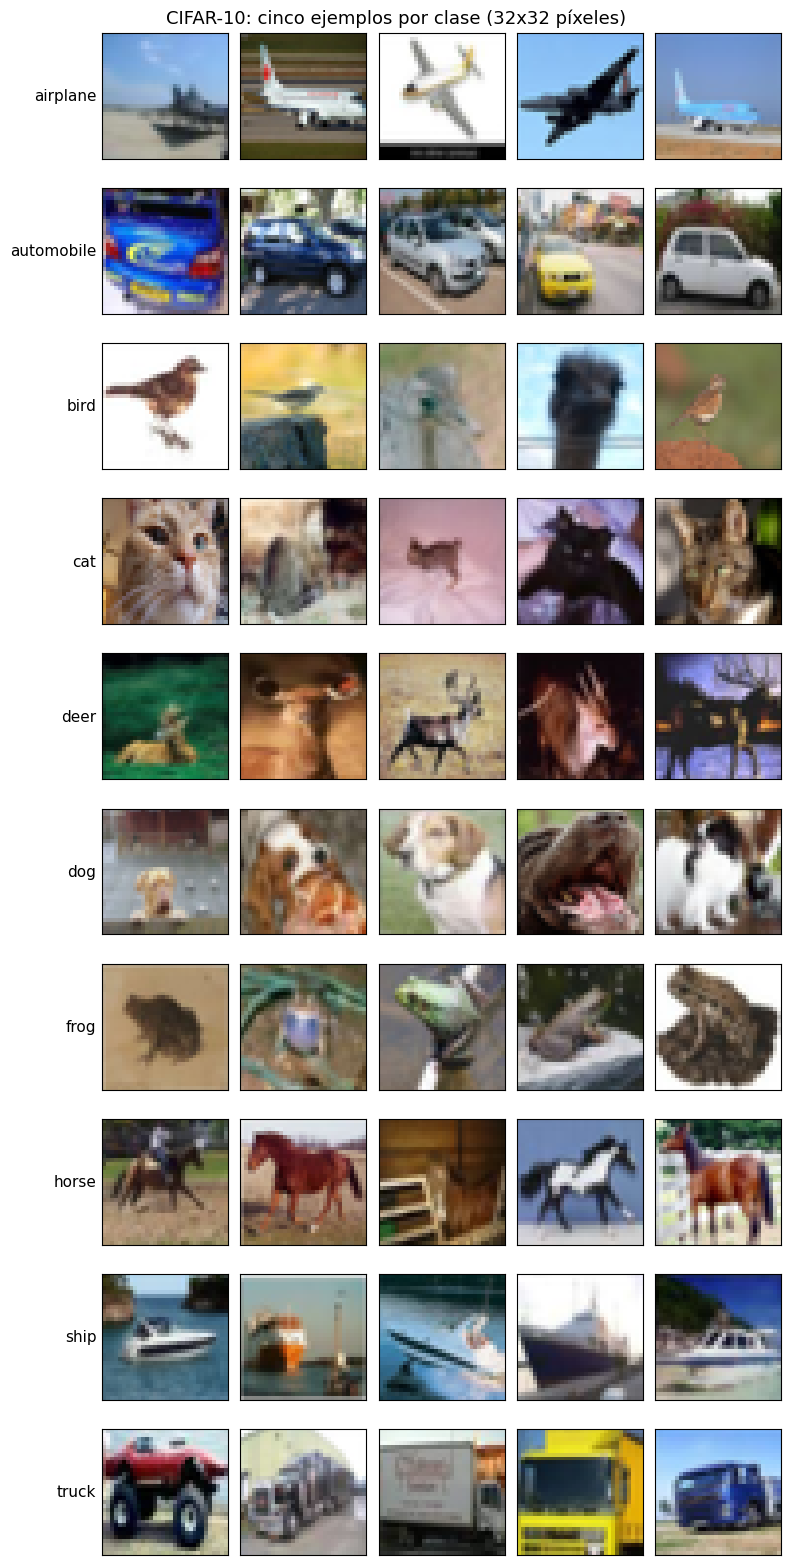

In [7]:
N_EJEMPLOS = 5
rng = np.random.default_rng(SEED)
etiquetas = np.array(train.targets)

fig, axes = plt.subplots(len(CLASES), N_EJEMPLOS, figsize=(N_EJEMPLOS * 1.6, len(CLASES) * 1.6))

# Por cada clase se eligen al azar cinco imágenes del conjunto de entrenamiento
for fila, clase in enumerate(CLASES):
    indices = rng.choice(np.where(etiquetas == fila)[0], size=N_EJEMPLOS, replace=False)
    for col, idx in enumerate(indices):
        ax = axes[fila, col]
        ax.imshow(train.data[idx])
        ax.set_xticks([])
        ax.set_yticks([])
    axes[fila, 0].set_ylabel(clase, rotation=0, ha="right", va="center", fontsize=11)

fig.suptitle("CIFAR-10: cinco ejemplos por clase (32x32 píxeles)", fontsize=13)
plt.tight_layout()
plt.show()

**¿Qué transformaciones de preprocesamiento necesita cada modelo? Defina un pipeline para la CNN desde cero (resolución nativa) y otro para VGG-16 (redimensionamiento y normalización de ImageNet). ¿Qué pasa con el número de píxeles, y por lo tanto con el cómputo, al pasar de 32x32 a 224x224?**

La CNN desde cero solo necesita `ToTensor`, que reordena las dimensiones a (canales, alto, ancho) y escala los valores al intervalo de 0 a 1, seguido de `Normalize` con las estadísticas de CIFAR-10, ya que se diseñará para trabajar directamente con la resolución nativa de 32x32. En el caso de VGG-16, primero se aplica `Resize`, pues sus filtros aprendieron a reconocer patrones a la escala de las imágenes de ImageNet, y para poder aprovechar ese conocimiento previo los objetos deben aparecer a un tamaño similar. Luego se aplican `ToTensor` y `Normalize` con las estadísticas de ImageNet. Cabe mencionar que no se utilizó el recorte central que incluye `weights.transforms()`, ya que las imágenes de CIFAR-10 están encuadradas sobre el objeto y el recorte eliminaría parte de este.

Al pasar de 32x32 a 224x224 el número de píxeles aumenta 49 veces, de 1,024 a 50,176 por canal, y dado que cada convolución recorre todas las posiciones de la imagen, su costo crece en la misma proporción. En VGG-16 esto se traduce en pasar de 0.44 a 15.48 GMACs por imagen, es decir, unas 35 veces más, ya que las capas densas del clasificador mantienen un costo fijo gracias al `AdaptiveAvgPool2d`. Además, redimensionar no agrega información, sino que solo interpola los píxeles existentes. Bajo este escenario, y considerando que se entrenará en una Mac, se utilizará una resolución de 128x128 para ambos modelos basados en VGG-16, lo cual reduce el costo a 5.14 GMACs por imagen, unas tres veces menos que a 224x224.

In [8]:
RESOLUCION_VGG = 128

# CNN desde cero: resolución nativa y normalización con las estadísticas de CIFAR-10
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_CIFAR.tolist(), STD_CIFAR.tolist()),
])

# VGG-16: redimensionamiento y normalización con las estadísticas de ImageNet
transform_vgg = transforms.Compose([
    transforms.Resize((RESOLUCION_VGG, RESOLUCION_VGG)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET.tolist(), STD_IMAGENET.tolist()),
])

imagen, etiqueta = train[0]
tensor_cnn = transform_cnn(imagen)
tensor_vgg = transform_vgg(imagen)

print(f"Entrada original: imagen PIL de {imagen.size[0]}x{imagen.size[1]}")
print(f"Tensor para la CNN: {tuple(tensor_cnn.shape)}, media {tensor_cnn.mean():.3f}, desv. {tensor_cnn.std():.3f}")
print(f"Tensor para VGG-16: {tuple(tensor_vgg.shape)}, media {tensor_vgg.mean():.3f}, desv. {tensor_vgg.std():.3f}")

Entrada original: imagen PIL de 32x32
Tensor para la CNN: (3, 32, 32), media -0.261, desv. 0.766
Tensor para VGG-16: (3, 128, 128), media -0.193, desv. 0.790


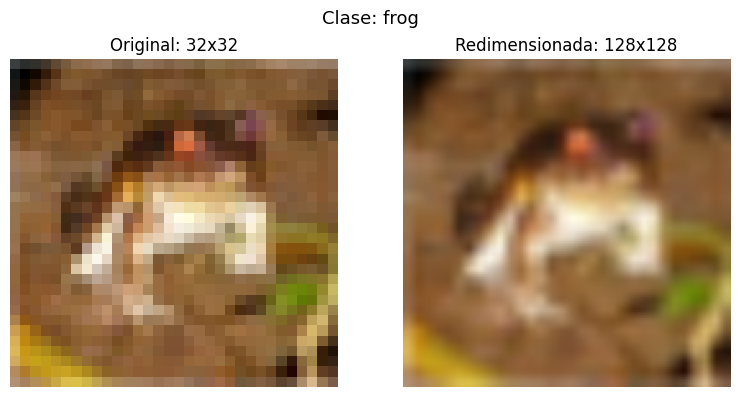

In [9]:
imagen, etiqueta = train[0]
imagen_redimensionada = transforms.Resize((RESOLUCION_VGG, RESOLUCION_VGG))(imagen)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.imshow(imagen)
ax1.set_title(f"Original: {imagen.size[0]}x{imagen.size[1]}")
ax1.axis("off")

ax2.imshow(imagen_redimensionada)
ax2.set_title(f"Redimensionada: {RESOLUCION_VGG}x{RESOLUCION_VGG}")
ax2.axis("off")

fig.suptitle(f"Clase: {CLASES[etiqueta]}", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
from torchinfo import summary

# Solo se necesita la arquitectura para contar operaciones, por lo que no se descargan los pesos
vgg_arquitectura = models.vgg16(weights=None)

filas = []
for resolucion in [32, 112, 128, 224]:
    info = summary(vgg_arquitectura, input_size=(1, 3, resolucion, resolucion), verbose=0)
    filas.append({
        "Resolución": f"{resolucion}x{resolucion}",
        "Píxeles por canal": resolucion * resolucion,
        "Veces los píxeles de 32x32": resolucion * resolucion / (32 * 32),
        "MACs de VGG-16 por imagen (G)": round(info.total_mult_adds / 1e9, 2),
    })

costo_resolucion = pd.DataFrame(filas)
costo_resolucion

,Resolución,Píxeles por canal,Veces los píxeles de 32x32,MACs de VGG-16 por imagen (G)
0,32x32,1024,1.00,0.44
1,112x112,12544,12.25,3.96
2,128x128,16384,16.00,5.14
3,224x224,50176,49.00,15.48


**¿Qué técnicas de data augmentation utilizarán y por qué? Justifique por qué la augmentation se aplica solo al conjunto de entrenamiento.**

Se utilizarán tres técnicas: `RandomHorizontalFlip`, que voltea la imagen horizontalmente con una probabilidad del 50 %; `RandomCrop`, que agrega un borde de 4 píxeles y recorta nuevamente una región de 32x32 en una posición aleatoria, simulando pequeños desplazamientos del objeto; y `ColorJitter`, que varía de forma leve el brillo, el contraste, la saturación y el tono. Las dos primeras se eligieron porque no alteran la clase de la imagen, ya que un gato volteado o ligeramente desplazado sigue siendo un gato. Por otro lado, con `ColorJitter` se busca evitar un sesgo por color. Por ejemplo, si 3,000 de las imágenes de gatos fueran de gatos anaranjados, el modelo podría asociar ese color con la clase, por lo que al variarlo se le obliga a enfocarse en formas y patrones más distintivos. En el caso de VGG-16, estas transformaciones se aplican sobre la imagen de 32x32 antes del redimensionamiento.

La augmentation se aplica únicamente al conjunto de entrenamiento porque su propósito es que el modelo vea una versión distinta de cada imagen en cada epoch, lo cual funciona como tener más datos y ayuda a reducir el overfitting. En validación y test, en cambio, se busca medir el desempeño sobre las imágenes tal como son, de tal forma que los resultados sean reproducibles y comparables entre iteraciones, ya que si se aplicaran transformaciones aleatorias la métrica cambiaría en cada evaluación aunque el modelo fuera el mismo.

In [11]:
# Transformaciones aleatorias, aplicadas sobre la imagen de 32x32 antes de cualquier otro paso
augmentation = [
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
]

# Entrenamiento: augmentation seguida del pipeline de cada modelo
transform_cnn_train = transforms.Compose(augmentation + transform_cnn.transforms)
transform_vgg_train = transforms.Compose(augmentation + transform_vgg.transforms)

# Validación y test: únicamente el pipeline de cada modelo, sin transformaciones aleatorias
transform_cnn_eval = transform_cnn
transform_vgg_eval = transform_vgg

print("Pipeline de entrenamiento de la CNN:")
print(transform_cnn_train)
print("\nPipeline de entrenamiento de VGG-16:")
print(transform_vgg_train)

Pipeline de entrenamiento de la CNN:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomCrop(size=(32, 32), padding=4)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.49140089750289917, 0.48215895891189575, 0.4465307891368866], std=[0.2470327913761139, 0.243484228849411, 0.261587530374527])
)

Pipeline de entrenamiento de VGG-16:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomCrop(size=(32, 32), padding=4)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


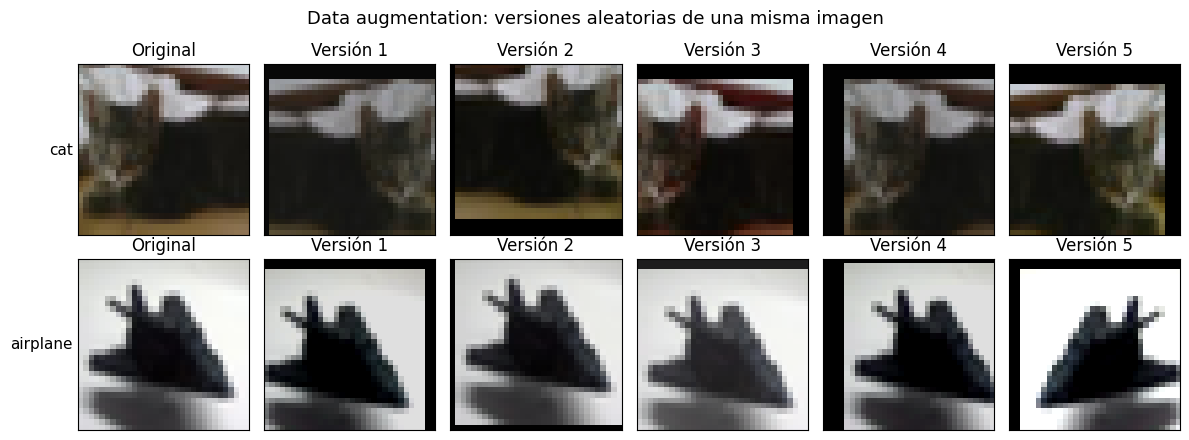

In [12]:
fijar_semilla()
aplicar_augmentation = transforms.Compose(augmentation)
N_VERSIONES = 5

# Se toma la primera imagen de gato y la primera de avión del conjunto de entrenamiento
indices_ejemplo = [np.where(etiquetas == CLASES.index(c))[0][0] for c in ["cat", "airplane"]]

fig, axes = plt.subplots(len(indices_ejemplo), N_VERSIONES + 1, figsize=(12, 4.5))

for fila, idx in enumerate(indices_ejemplo):
    imagen, etiqueta = train[idx]
    axes[fila, 0].imshow(imagen)
    axes[fila, 0].set_title("Original")
    for col in range(1, N_VERSIONES + 1):
        axes[fila, col].imshow(aplicar_augmentation(imagen))
        axes[fila, col].set_title(f"Versión {col}")
    axes[fila, 0].set_ylabel(CLASES[etiqueta], rotation=0, ha="right", va="center", fontsize=11)
    for ax in axes[fila]:
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Data augmentation: versiones aleatorias de una misma imagen", fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# División estratificada: 45,000 imágenes para entrenamiento y 5,000 para validación
indices_train, indices_val = train_test_split(
    np.arange(len(train)),
    test_size=5000,
    stratify=etiquetas,
    random_state=SEED,
)


def crear_conjuntos(transform_train, transform_eval):
    """Retorna los conjuntos de entrenamiento, validación y test con los pipelines de un modelo."""
    # Se crean dos instancias del conjunto original para que la validación no reciba augmentation
    base_train = datasets.CIFAR10(root=DATA_DIR, train=True, transform=transform_train)
    base_eval = datasets.CIFAR10(root=DATA_DIR, train=True, transform=transform_eval)
    conjunto_test = datasets.CIFAR10(root=DATA_DIR, train=False, transform=transform_eval)
    return Subset(base_train, indices_train), Subset(base_eval, indices_val), conjunto_test


train_cnn, val_cnn, test_cnn = crear_conjuntos(transform_cnn_train, transform_cnn_eval)
train_vgg, val_vgg, test_vgg = crear_conjuntos(transform_vgg_train, transform_vgg_eval)

print(f"Entrenamiento: {len(train_cnn)} imágenes")
print(f"Validación: {len(val_cnn)} imágenes")
print(f"Test: {len(test_cnn)} imágenes")

# Se verifica que la estratificación mantenga el balance de clases en ambos conjuntos
pd.DataFrame({
    "Imágenes (train)": pd.Series(etiquetas[indices_train]).map(lambda i: CLASES[i]).value_counts(),
    "Imágenes (val)": pd.Series(etiquetas[indices_val]).map(lambda i: CLASES[i]).value_counts(),
}).reindex(CLASES)

Entrenamiento: 45000 imágenes
Validación: 5000 imágenes
Test: 10000 imágenes


,Imágenes (train),Imágenes (val)
airplane,4500,500
automobile,4500,500
bird,4500,500
cat,4500,500
deer,4500,500
dog,4500,500
frog,4500,500
horse,4500,500
ship,4500,500
truck,4500,500


---
# **3. Investigación: transfer learning en PyTorch**

El transfer learning es una técnica que permite reutilizar un modelo entrenado previamente y adaptarlo a una nueva tarea. En clasificación de imágenes, una aplicación común consiste en conservar las capas que extraen características visuales y modificar las capas finales para reconocer otras categorías. PyTorch y TorchVision ofrecen las herramientas necesarias para realizar este proceso y evaluar su costo computacional.

**torchvision.models.vgg16 y VGG16_Weights (incluyendo weights.transforms())**

La función `torchvision.models.vgg16()` crea un modelo con la arquitectura VGG16. Su parámetro `weights` determina si se cargan pesos preentrenados. Al utilizar `VGG16_Weights.DEFAULT` o `VGG16_Weights.IMAGENET1K_V1`, que fue la utilizada en este laboratorio, se obtienen pesos entrenados para clasificar imágenes de ImageNet; con `weights=None`, el modelo se inicializa sin ellos, lo cual se utilizó únicamente para contar operaciones sin descargar los pesos. El parámetro `progress` controla si se muestra el avance de la descarga. Además, `VGG16_Weights` incluye `weights.transforms()`, una transformación que prepara las imágenes para la inferencia redimensionándolas a 256 píxeles, aplicando un recorte central de 224x224 y normalizando los canales con las estadísticas de ImageNet. Sin embargo, en este laboratorio no se utilizó directamente, ya que las imágenes de CIFAR-10 están encuadradas sobre el objeto y el recorte eliminaría parte de este, por lo que se definió un pipeline propio que redimensiona directamente a 128x128 y conserva la misma normalización.

**Estructura del modelo: model.features, model.avgpool (nn.AdaptiveAvgPool2d) y model.classifier**

La estructura de VGG16 se divide en tres componentes principales. `model.features` contiene las capas convolucionales encargadas de extraer características de la imagen, organizadas en cinco bloques que inician en los índices 0, 5, 10, 17 y 24. `model.avgpool` aplica un agrupamiento promedio adaptativo mediante `nn.AdaptiveAvgPool2d((7, 7))`, de modo que la salida tenga un tamaño espacial fijo antes de ingresar al clasificador. El parámetro principal de esta clase es `output_size`, que establece las dimensiones de salida. Esto es lo que permite trabajar con imágenes de 128x128, pues los bloques convolucionales entregan un mapa de 4x4 que esta capa lleva a 7x7, manteniendo la entrada de 25,088 valores que espera el clasificador; cabe mencionar que MPS no soporta esta conversión, por lo que esta capa se ejecutó en CPU. Por último, `model.classifier` contiene las capas que generan la predicción. Para adaptar VGG16 a un problema con otro número de categorías, se puede reemplazar su última capa lineal, ubicada en `model.classifier[6]`, que en este caso se sustituyó por una capa de 4,096 a 10 salidas.

**requires_grad y cómo congelar / descongelar capas o bloques completos**

La propiedad `requires_grad` indica si PyTorch debe calcular gradientes para un parámetro. Al establecerla en `False`, el parámetro queda congelado y no se actualiza durante el entrenamiento. Para congelar una capa o un bloque completo, se cambia esta propiedad en todos sus parámetros. El proceso inverso consiste en establecer `requires_grad=True`. En el feature extractor se congeló todo `model.features`, mientras que en el fine-tuning se descongelaron los parámetros a partir del bloque correspondiente, por ejemplo `model.features[24:]` para el bloque 5 o `model.features[17:]` para los bloques 4 y 5. Los parámetros descongelados deben estar incluidos en el optimizador para que puedan actualizarse. Cabe mencionar que una estrategia alternativa consiste en entrenar primero el nuevo clasificador y después descongelar los bloques; no obstante, en este laboratorio el fine-tuning se entrenó directamente con los bloques descongelados y el nuevo clasificador al mismo tiempo, controlando el ajuste mediante learning rates distintos.

**model.train() vs. model.eval() y torch.no_grad()**

`model.train()` activa el modo de entrenamiento, mientras que `model.eval()` activa el modo de evaluación. Esta distinción modifica el comportamiento de ciertos componentes, como las capas dropout, que se desactivan al evaluar, y las capas de batch normalization de la CNN, que en entrenamiento utilizan las estadísticas de cada batch y en evaluación las estadísticas acumuladas. Por otra parte, `torch.no_grad()` desactiva temporalmente el cálculo de gradientes, lo que resulta útil durante la validación y la inferencia porque reduce el uso de memoria. `model.eval()` y `torch.no_grad()` cumplen funciones diferentes y normalmente se utilizan juntos al realizar predicciones, como se hizo en la función de evaluación, en la extracción de features y en la medición de latencia.

**Grupos de parámetros en el optimizador (param_groups) para usar learning rates distintos por capa**

Los grupos de parámetros del optimizador, llamados `param_groups`, permiten aplicar distintas opciones de entrenamiento a diferentes partes del modelo. Cada grupo especifica sus parámetros mediante `params` y puede definir una tasa de aprendizaje propia mediante `lr`. En el fine-tuning se definieron dos grupos en AdamW: los bloques descongelados con un learning rate de 1e-5 o 1e-4, según la iteración, y el clasificador con 1e-4, buscando ajustar ligeramente los pesos preentrenados sin destruir lo aprendido en ImageNet. Los grupos también pueden tener valores diferentes para otras opciones, como `weight_decay`.

**Una herramienta para contar parámetros y operaciones: torchinfo, fvcore, thop o ptflops**

Para estimar el costo computacional se utilizó torchinfo. Su función `summary()` recibe el modelo y el tamaño de una entrada de ejemplo mediante `input_size`, y reporta la forma de salida y los parámetros de cada capa, el total de parámetros y entrenables, y el número de operaciones MAC, que denomina mult-adds y que se obtiene con el atributo `total_mult_adds`. El parámetro `device` indica dónde se realiza el cálculo, y `verbose` controla cuánta información se imprime. Las dimensiones de la entrada son relevantes, ya que el número de operaciones varía con el tamaño de las imágenes, como se observó al pasar de 0.44 a 15.48 GMACs en VGG-16 entre 32x32 y 224x224. Otras herramientas como THOP ofrecen funciones similares, por ejemplo `profile()`, que retorna los MACs y los parámetros de un modelo.

**torch.cuda.max_memory_allocated() y torch.cuda.synchronize() para medir memoria y tiempo en GPU**

Cuando se utiliza una GPU CUDA, `torch.cuda.max_memory_allocated(device)` permite consultar el máximo de memoria asignada a tensores, expresado en bytes. El argumento `device` es opcional e indica la GPU que se desea medir. Para obtener el pico correspondiente a una prueba específica, es conveniente reiniciar las estadísticas de memoria antes de ejecutarla. La función `torch.cuda.synchronize(device)` espera a que finalicen las operaciones pendientes en la GPU. Debido a que las operaciones en la GPU pueden ser asíncronas, esta sincronización es necesaria antes de iniciar y después de detener un cronómetro si se desea medir correctamente el tiempo de ejecución. Dado que este laboratorio se ejecutó sobre la GPU de Apple (MPS), se utilizaron sus equivalentes: `torch.mps.synchronize()` para medir los tiempos y `torch.mps.current_allocated_memory()` para registrar la memoria después de cada forward, conservando el valor máximo como memoria pico, ya que MPS no ofrece una función de memoria máxima.

**Diferencia entre MACs y FLOPs y cómo se relacionan**

Un MAC corresponde a una operación de multiplicación y acumulación. Los FLOPs representan operaciones de punto flotante. Si la multiplicación y la suma se cuentan por separado, un MAC equivale aproximadamente a dos FLOPs. Sin embargo, algunas herramientas consideran la operación combinada como una sola. Por ello, las cifras de distintas herramientas no deben compararse sin revisar primero su criterio de conteo. En este laboratorio torchinfo reporta MACs, por lo que los FLOPs se obtuvieron multiplicándolos por dos.

**Diferencia entre parámetros totales y parámetros entrenables**

Los parámetros totales comprenden todos los pesos y sesgos del modelo. Los parámetros entrenables son el subconjunto que tiene `requires_grad=True` y que puede actualizarse durante el entrenamiento. Congelar capas reduce el número de parámetros entrenables, pero no elimina esas capas del modelo ni las operaciones que realizan al procesar una imagen. Por ejemplo, el feature extractor tiene 134.3 millones de parámetros totales, de los cuales solo 119.6 millones son entrenables, pero cada imagen sigue requiriendo los 5.135 GMACs de VGG-16 completa.

---
# **4. Construcción y entrenamiento de los modelos**

## **Configuración del entrenamiento**

In [14]:
import gc
import json
from pathlib import Path

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

BATCH_SIZE = 128
NUM_WORKERS = 4

DIR_MODELOS = Path("modelos")
DIR_RESULTADOS = Path("resultados")
DIR_MODELOS.mkdir(exist_ok=True)
DIR_RESULTADOS.mkdir(exist_ok=True)

criterio = nn.CrossEntropyLoss()


def crear_loaders(conjunto_train, conjunto_val, num_workers=NUM_WORKERS):
    """Crea los DataLoaders de entrenamiento (mezclado) y validación (en orden)."""
    generador = torch.Generator().manual_seed(SEED)
    loader_train = DataLoader(conjunto_train, batch_size=BATCH_SIZE, shuffle=True, generator=generador,
                              num_workers=num_workers, persistent_workers=num_workers > 0)
    loader_val = DataLoader(conjunto_val, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=num_workers, persistent_workers=num_workers > 0)
    return loader_train, loader_val


def sincronizar():
    """Espera a que la GPU termine las operaciones pendientes, para que los tiempos medidos sean reales."""
    if DEVICE.type == "mps":
        torch.mps.synchronize()


def memoria_actual_mb():
    """Memoria ocupada por tensores en la GPU de Apple, en MB."""
    if DEVICE.type == "mps":
        return torch.mps.current_allocated_memory() / 1024**2
    return 0.0


def liberar_memoria():
    """Libera la memoria de modelos anteriores antes de iniciar una nueva iteración."""
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()

## **Funciones de entrenamiento y evaluación**

In [15]:
def contar_parametros(modelo):
    """Retorna el número de parámetros totales y entrenables de un modelo."""
    totales = sum(p.numel() for p in modelo.parameters())
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return totales, entrenables


def evaluar(modelo, loader):
    """Calcula la pérdida y las métricas macro de un modelo sobre un conjunto de datos."""
    modelo.eval()
    suma_loss, reales, predichas = 0.0, [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            salida = modelo(x)
            suma_loss += criterio(salida, y).item() * len(y)
            reales.append(y.cpu())
            predichas.append(salida.argmax(dim=1).cpu())

    reales = torch.cat(reales).numpy()
    predichas = torch.cat(predichas).numpy()
    precision, recall, f1, _ = precision_recall_fscore_support(reales, predichas, average="macro", zero_division=0)
    metricas = {
        "loss": suma_loss / len(reales),
        "accuracy": accuracy_score(reales, predichas),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }
    return metricas, reales, predichas


def entrenar_modelo(modelo, optimizador, loader_train, loader_val, max_epochs, paciencia, ruta_pesos):
    """Entrena con early stopping sobre la pérdida de validación y guarda los pesos de la mejor epoch."""
    historial = {"loss_train": [], "loss_val": [], "accuracy_val": [], "f1_val": [], "tiempo_epoch": []}
    mejor_loss, mejor_epoch, mejores_metricas = float("inf"), 0, None
    epochs_sin_mejora = 0
    memoria_pico = 0.0

    for epoch in range(1, max_epochs + 1):
        modelo.train()
        suma_loss = torch.zeros(1, device=DEVICE)
        n_imagenes = 0

        sincronizar()
        inicio = time.perf_counter()
        for x, y in loader_train:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizador.zero_grad()
            loss = criterio(modelo(x), y)
            # Después del forward es cuando más memoria se ocupa, ya que se guardan las activaciones
            memoria_pico = max(memoria_pico, memoria_actual_mb())
            loss.backward()
            optimizador.step()
            suma_loss += loss.detach() * len(y)
            n_imagenes += len(y)
        sincronizar()
        tiempo_epoch = time.perf_counter() - inicio

        metricas_val, _, _ = evaluar(modelo, loader_val)
        historial["loss_train"].append(suma_loss.item() / n_imagenes)
        historial["loss_val"].append(metricas_val["loss"])
        historial["accuracy_val"].append(metricas_val["accuracy"])
        historial["f1_val"].append(metricas_val["f1"])
        historial["tiempo_epoch"].append(tiempo_epoch)

        print(f"Epoch {epoch}/{max_epochs}: loss train {historial['loss_train'][-1]:.4f}, "
              f"loss val {metricas_val['loss']:.4f}, accuracy val {metricas_val['accuracy']:.4f}, "
              f"f1 val {metricas_val['f1']:.4f}, tiempo {tiempo_epoch:.1f} s")

        if metricas_val["loss"] < mejor_loss:
            mejor_loss, mejor_epoch, mejores_metricas = metricas_val["loss"], epoch, metricas_val
            torch.save(modelo.state_dict(), ruta_pesos)
            epochs_sin_mejora = 0
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= paciencia:
                print(f"Early stopping: la pérdida de validación no mejoró en {paciencia} epochs")
                break

    return historial, mejor_epoch, mejores_metricas, memoria_pico

In [16]:
RUTA_REGISTRO = DIR_RESULTADOS / "registro_iteraciones.json"

# El registro se guarda en disco para no perder las iteraciones ya entrenadas si se reinicia el kernel
registro = json.loads(RUTA_REGISTRO.read_text()) if RUTA_REGISTRO.exists() else {}


def ejecutar_iteracion(nombre, tipo, config, crear_modelo, crear_optimizador, loader_train, loader_val,
                       max_epochs, paciencia, parametros=None, tiempo_adicional=0.0):
    """Entrena una iteración, la agrega al registro y la guarda en disco.

    Si la iteración ya existe en el registro no se vuelve a entrenar; para repetirla se debe
    eliminar su entrada con registro.pop(nombre).
    """
    if nombre in registro:
        print(f"{nombre} ya se encuentra en el registro, se reutilizan sus resultados")
        return registro[nombre]

    print(f"Iteración {nombre} ({tipo}): {config}")
    liberar_memoria()
    fijar_semilla()
    modelo = crear_modelo().to(DEVICE)
    optimizador = crear_optimizador(modelo)
    totales, entrenables = parametros if parametros is not None else contar_parametros(modelo)
    ruta_pesos = DIR_MODELOS / f"{nombre}.pt"

    inicio = time.perf_counter()
    historial, mejor_epoch, metricas, memoria_pico = entrenar_modelo(
        modelo, optimizador, loader_train, loader_val, max_epochs, paciencia, ruta_pesos)
    tiempo_total = time.perf_counter() - inicio + tiempo_adicional

    registro[nombre] = {
        "tipo": tipo,
        "config": config,
        "parametros_totales": totales,
        "parametros_entrenables": entrenables,
        "historial": historial,
        "mejor_epoch": mejor_epoch,
        "epochs_ejecutadas": len(historial["loss_train"]),
        **{f"{metrica}_val": valor for metrica, valor in metricas.items()},
        "tiempo_promedio_epoch": float(np.mean(historial["tiempo_epoch"])),
        "tiempo_total": tiempo_total,
        "memoria_pico_mb": memoria_pico,
        "ruta_pesos": str(ruta_pesos),
    }
    RUTA_REGISTRO.write_text(json.dumps(registro, indent=2))

    del modelo, optimizador
    liberar_memoria()
    return registro[nombre]


def graficar_curvas(nombres, titulo):
    """Grafica la pérdida de entrenamiento y validación por epoch de cada iteración."""
    fig, axes = plt.subplots(1, len(nombres), figsize=(5 * len(nombres), 4))
    for ax, nombre in zip(np.atleast_1d(axes), nombres):
        historial = registro[nombre]["historial"]
        epochs = range(1, len(historial["loss_train"]) + 1)
        ax.plot(epochs, historial["loss_train"], marker="o", label="Entrenamiento")
        ax.plot(epochs, historial["loss_val"], marker="o", label="Validación")
        ax.axvline(registro[nombre]["mejor_epoch"], color="gray", linestyle=":", label="Mejor epoch")
        ax.set_title(nombre)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Pérdida (cross-entropy)")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

## **CNN desde cero**

In [17]:
def crear_cnn(filtros=(32, 64, 128), dropout=0.3, neuronas=256):
    """CNN con un bloque convolucional por cada valor de filtros; cada bloque reduce la imagen a la mitad."""
    capas = []
    canales_entrada = 3
    for canales in filtros:
        capas += [
            nn.Conv2d(canales_entrada, canales, kernel_size=3, padding=1),
            nn.BatchNorm2d(canales),
            nn.ReLU(),
            nn.Conv2d(canales, canales, kernel_size=3, padding=1),
            nn.BatchNorm2d(canales),
            nn.ReLU(),
            nn.MaxPool2d(2),
        ]
        canales_entrada = canales

    lado = 32 // 2 ** len(filtros)
    capas += [
        nn.Flatten(),
        nn.Dropout(dropout),
        nn.Linear(canales_entrada * lado * lado, neuronas),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(neuronas, len(CLASES)),
    ]
    return nn.Sequential(*capas)


summary(crear_cnn(), input_size=(1, 3, 32, 32), col_names=["output_size", "num_params"], verbose=0)

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 32, 32]           896
├─BatchNorm2d: 1-2                       [1, 32, 32, 32]           64
├─ReLU: 1-3                              [1, 32, 32, 32]           --
├─Conv2d: 1-4                            [1, 32, 32, 32]           9,248
├─BatchNorm2d: 1-5                       [1, 32, 32, 32]           64
├─ReLU: 1-6                              [1, 32, 32, 32]           --
├─MaxPool2d: 1-7                         [1, 32, 16, 16]           --
├─Conv2d: 1-8                            [1, 64, 16, 16]           18,496
├─BatchNorm2d: 1-9                       [1, 64, 16, 16]           128
├─ReLU: 1-10                             [1, 64, 16, 16]           --
├─Conv2d: 1-11                           [1, 64, 16, 16]           36,928
├─BatchNorm2d: 1-12                      [1, 64, 16, 16]           128
├

In [18]:
MAX_EPOCHS_CNN = 20
PACIENCIA_CNN = 3

iteraciones_cnn = [
    {"nombre": "cnn_1", "filtros": [32, 64, 128], "dropout": 0.3, "lr": 1e-3, "weight_decay": 0.0},
    {"nombre": "cnn_2", "filtros": [64, 128, 256], "dropout": 0.3, "lr": 1e-3, "weight_decay": 0.0},
    {"nombre": "cnn_3", "filtros": [64, 128, 256], "dropout": 0.5, "lr": 1e-3, "weight_decay": 5e-4},
]

loader_train_cnn, loader_val_cnn = crear_loaders(train_cnn, val_cnn)

for cfg in iteraciones_cnn:
    ejecutar_iteracion(
        nombre=cfg["nombre"],
        tipo="CNN desde cero",
        config=cfg,
        crear_modelo=lambda: crear_cnn(cfg["filtros"], cfg["dropout"]),
        crear_optimizador=lambda m: torch.optim.AdamW(m.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]),
        loader_train=loader_train_cnn,
        loader_val=loader_val_cnn,
        max_epochs=MAX_EPOCHS_CNN,
        paciencia=PACIENCIA_CNN,
    )
    print()

Iteración cnn_1 (CNN desde cero): {'nombre': 'cnn_1', 'filtros': [32, 64, 128], 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0}
Epoch 1/20: loss train 1.5458, loss val 1.2168, accuracy val 0.5696, f1 val 0.5626, tiempo 21.6 s
Epoch 2/20: loss train 1.0912, loss val 1.0089, accuracy val 0.6492, f1 val 0.6372, tiempo 11.2 s
Epoch 3/20: loss train 0.9237, loss val 0.9774, accuracy val 0.6670, f1 val 0.6584, tiempo 11.6 s
Epoch 4/20: loss train 0.8216, loss val 0.7737, accuracy val 0.7206, f1 val 0.7150, tiempo 11.9 s
Epoch 5/20: loss train 0.7592, loss val 0.6955, accuracy val 0.7518, f1 val 0.7436, tiempo 12.1 s
Epoch 6/20: loss train 0.7105, loss val 0.9625, accuracy val 0.6836, f1 val 0.6867, tiempo 11.8 s
Epoch 7/20: loss train 0.6707, loss val 0.7070, accuracy val 0.7660, f1 val 0.7607, tiempo 11.6 s
Epoch 8/20: loss train 0.6303, loss val 0.6028, accuracy val 0.7898, f1 val 0.7923, tiempo 11.6 s
Epoch 9/20: loss train 0.6017, loss val 0.5490, accuracy val 0.8132, f1 val 0.8111, ti

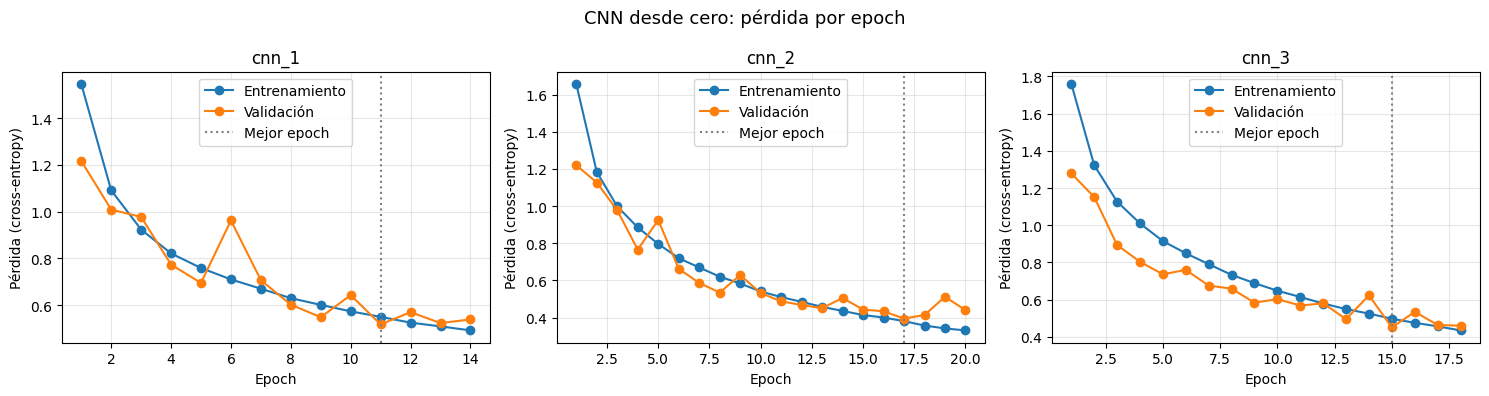

In [19]:
graficar_curvas([cfg["nombre"] for cfg in iteraciones_cnn], "CNN desde cero: pérdida por epoch")

## **VGG-16 como feature extractor**

In [20]:
# Índice en model.features donde inicia cada uno de los cinco bloques convolucionales de VGG-16
INICIO_BLOQUES_VGG = {1: 0, 2: 5, 3: 10, 4: 17, 5: 24}


class AvgPoolCPU(nn.Module):
    """Ejecuta el AdaptiveAvgPool2d de VGG-16 en CPU, ya que MPS no soporta pasar de un mapa de 4x4 a 7x7."""

    def __init__(self, pool):
        super().__init__()
        self.pool = pool

    def forward(self, x):
        return self.pool(x.cpu()).to(x.device)


def crear_vgg(bloques_descongelados=0):
    """VGG-16 preentrenada en ImageNet con los últimos bloques descongelados y una salida de 10 clases."""
    modelo = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

    for parametro in modelo.features.parameters():
        parametro.requires_grad = False
    if bloques_descongelados > 0:
        inicio = INICIO_BLOQUES_VGG[6 - bloques_descongelados]
        for parametro in modelo.features[inicio:].parameters():
            parametro.requires_grad = True

    modelo.avgpool = AvgPoolCPU(modelo.avgpool)
    modelo.classifier[6] = nn.Linear(4096, len(CLASES))
    return modelo


vgg_base = crear_vgg(bloques_descongelados=0)
PARAMETROS_FE = contar_parametros(vgg_base)

print(f"Parámetros totales: {PARAMETROS_FE[0]:,}")
print(f"Parámetros entrenables: {PARAMETROS_FE[1]:,}")
print(vgg_base.classifier)

Parámetros totales: 134,301,514
Parámetros entrenables: 119,586,826
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=10, bias=True)
)


In [21]:
def extraer_features(backbone, conjunto):
    """Pasa un conjunto una sola vez por el backbone congelado y guarda sus salidas en memoria."""
    loader = DataLoader(conjunto, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    lista_x, lista_y = [], []
    backbone.eval()
    with torch.no_grad():
        for x, y in loader:
            lista_x.append(backbone(x.to(DEVICE)).cpu())
            lista_y.append(y)
    return TensorDataset(torch.cat(lista_x), torch.cat(lista_y))


# El feature extractor no utiliza augmentation para que las features de cada imagen sean siempre las mismas
train_vgg_sin_augmentation = Subset(
    datasets.CIFAR10(root=DATA_DIR, train=True, transform=transform_vgg_eval), indices_train)

backbone = vgg_base.features.to(DEVICE)
sincronizar()
inicio = time.perf_counter()
features_train = extraer_features(backbone, train_vgg_sin_augmentation)
features_val = extraer_features(backbone, val_vgg)
sincronizar()
TIEMPO_EXTRACCION = time.perf_counter() - inicio

print(f"Features de entrenamiento: {tuple(features_train.tensors[0].shape)}")
print(f"Features de validación: {tuple(features_val.tensors[0].shape)}")
print(f"Tiempo de extracción: {TIEMPO_EXTRACCION / 60:.1f} min")

del backbone, vgg_base
liberar_memoria()

Features de entrenamiento: (45000, 512, 4, 4)
Features de validación: (5000, 512, 4, 4)
Tiempo de extracción: 4.2 min


In [22]:
def crear_cabeza_fe():
    """Parte entrenable del feature extractor: el pooling y el clasificador de VGG-16."""
    modelo = crear_vgg(bloques_descongelados=0)
    return nn.Sequential(modelo.avgpool, nn.Flatten(), modelo.classifier)


MAX_EPOCHS_FE = 15
PACIENCIA_FE = 3

iteraciones_fe = [
    {"nombre": "fe_1", "lr": 1e-3, "weight_decay": 0.0},
    {"nombre": "fe_2", "lr": 1e-4, "weight_decay": 0.0},
    {"nombre": "fe_3", "lr": 1e-4, "weight_decay": 5e-4},
]

# Las features ya están en memoria, por lo que no se necesitan procesos adicionales para cargarlas
loader_train_fe, loader_val_fe = crear_loaders(features_train, features_val, num_workers=0)

for cfg in iteraciones_fe:
    ejecutar_iteracion(
        nombre=cfg["nombre"],
        tipo="VGG-16 feature extractor",
        config={**cfg, "capas_congeladas": "features completo (bloques 1 a 5)"},
        crear_modelo=crear_cabeza_fe,
        crear_optimizador=lambda m: torch.optim.AdamW(m.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]),
        loader_train=loader_train_fe,
        loader_val=loader_val_fe,
        max_epochs=MAX_EPOCHS_FE,
        paciencia=PACIENCIA_FE,
        parametros=PARAMETROS_FE,
        tiempo_adicional=TIEMPO_EXTRACCION,
    )
    print()

Iteración fe_1 (VGG-16 feature extractor): {'nombre': 'fe_1', 'lr': 0.001, 'weight_decay': 0.0, 'capas_congeladas': 'features completo (bloques 1 a 5)'}
Epoch 1/15: loss train 0.6661, loss val 0.5075, accuracy val 0.8390, f1 val 0.8385, tiempo 82.8 s
Epoch 2/15: loss train 0.5367, loss val 0.4132, accuracy val 0.8628, f1 val 0.8642, tiempo 68.0 s
Epoch 3/15: loss train 0.4683, loss val 0.4179, accuracy val 0.8774, f1 val 0.8778, tiempo 62.5 s
Epoch 4/15: loss train 0.4230, loss val 0.4140, accuracy val 0.8666, f1 val 0.8668, tiempo 65.2 s
Epoch 5/15: loss train 0.3795, loss val 0.4020, accuracy val 0.8828, f1 val 0.8833, tiempo 61.6 s
Epoch 6/15: loss train 0.3574, loss val 0.4106, accuracy val 0.8714, f1 val 0.8707, tiempo 114.7 s
Epoch 7/15: loss train 0.3226, loss val 0.4171, accuracy val 0.8774, f1 val 0.8774, tiempo 61.6 s
Epoch 8/15: loss train 0.3375, loss val 0.4092, accuracy val 0.8824, f1 val 0.8827, tiempo 62.8 s
Early stopping: la pérdida de validación no mejoró en 3 epochs

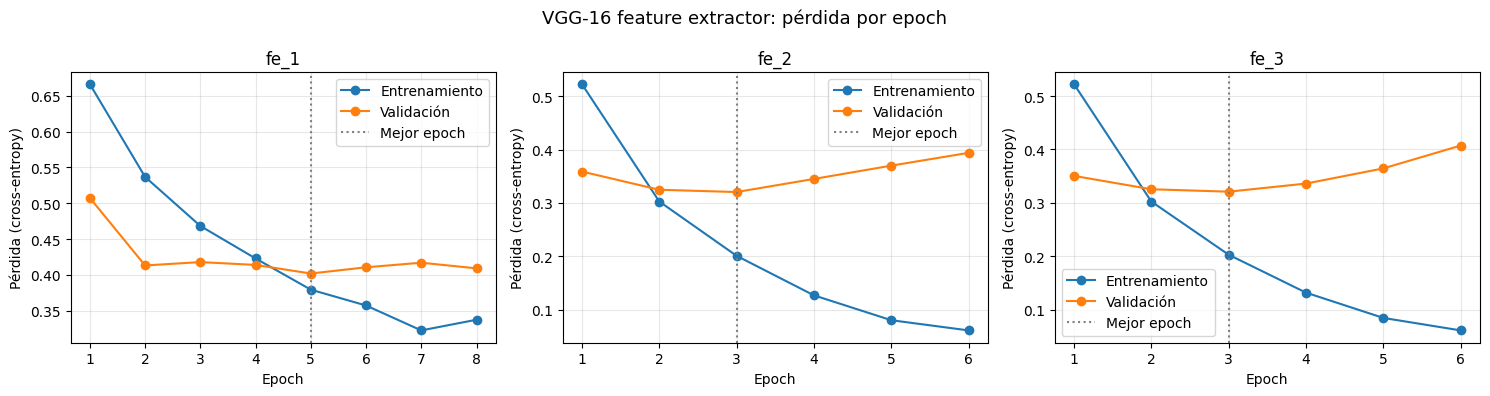

In [23]:
graficar_curvas([cfg["nombre"] for cfg in iteraciones_fe], "VGG-16 feature extractor: pérdida por epoch")

## **VGG-16 con fine-tuning**

In [24]:
def optimizador_fine_tuning(modelo, lr_backbone, lr_clasificador, weight_decay=0.0):
    """AdamW con un learning rate menor para los bloques descongelados que para el clasificador."""
    backbone = [p for p in modelo.features.parameters() if p.requires_grad]
    return torch.optim.AdamW([
        {"params": backbone, "lr": lr_backbone},
        {"params": modelo.classifier.parameters(), "lr": lr_clasificador},
    ], weight_decay=weight_decay)


MAX_EPOCHS_FT = 5
PACIENCIA_FT = 2

iteraciones_ft = [
    {"nombre": "ft_1", "bloques_descongelados": 1, "lr_backbone": 1e-5, "lr_clasificador": 1e-4},
    {"nombre": "ft_2", "bloques_descongelados": 2, "lr_backbone": 1e-5, "lr_clasificador": 1e-4},
    {"nombre": "ft_3", "bloques_descongelados": 1, "lr_backbone": 1e-4, "lr_clasificador": 1e-4},
]

loader_train_ft, loader_val_ft = crear_loaders(train_vgg, val_vgg)

for cfg in iteraciones_ft:
    congelados = 5 - cfg["bloques_descongelados"]
    ejecutar_iteracion(
        nombre=cfg["nombre"],
        tipo="VGG-16 fine-tuning",
        config={**cfg, "capas_congeladas": f"bloques 1 a {congelados}"},
        crear_modelo=lambda: crear_vgg(cfg["bloques_descongelados"]),
        crear_optimizador=lambda m: optimizador_fine_tuning(m, cfg["lr_backbone"], cfg["lr_clasificador"]),
        loader_train=loader_train_ft,
        loader_val=loader_val_ft,
        max_epochs=MAX_EPOCHS_FT,
        paciencia=PACIENCIA_FT,
    )
    print()

Iteración ft_1 (VGG-16 fine-tuning): {'nombre': 'ft_1', 'bloques_descongelados': 1, 'lr_backbone': 1e-05, 'lr_clasificador': 0.0001, 'capas_congeladas': 'bloques 1 a 4'}


Python(38307) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(38314) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(38315) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(38328) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(39275) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(39308) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(39329) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(39330) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 1/5: loss train 0.5880, loss val 0.3392, accuracy val 0.8788, f1 val 0.8781, tiempo 280.2 s
Epoch 2/5: loss train 0.3991, loss val 0.2919, accuracy val 0.8964, f1 val 0.8961, tiempo 253.4 s
Epoch 3/5: loss train 0.3352, loss val 0.2781, accuracy val 0.9032, f1 val 0.9028, tiempo 234.0 s
Epoch 4/5: loss train 0.2962, loss val 0.2510, accuracy val 0.9152, f1 val 0.9154, tiempo 253.7 s
Epoch 5/5: loss train 0.2703, loss val 0.2639, accuracy val 0.9112, f1 val 0.9105, tiempo 260.5 s

Iteración ft_2 (VGG-16 fine-tuning): {'nombre': 'ft_2', 'bloques_descongelados': 2, 'lr_backbone': 1e-05, 'lr_clasificador': 0.0001, 'capas_congeladas': 'bloques 1 a 3'}
Epoch 1/5: loss train 0.5282, loss val 0.2829, accuracy val 0.9018, f1 val 0.9008, tiempo 384.2 s
Epoch 2/5: loss train 0.3178, loss val 0.2270, accuracy val 0.9214, f1 val 0.9211, tiempo 382.2 s
Epoch 3/5: loss train 0.2539, loss val 0.2317, accuracy val 0.9228, f1 val 0.9224, tiempo 328.0 s
Epoch 4/5: loss train 0.2152, loss val 0.1930

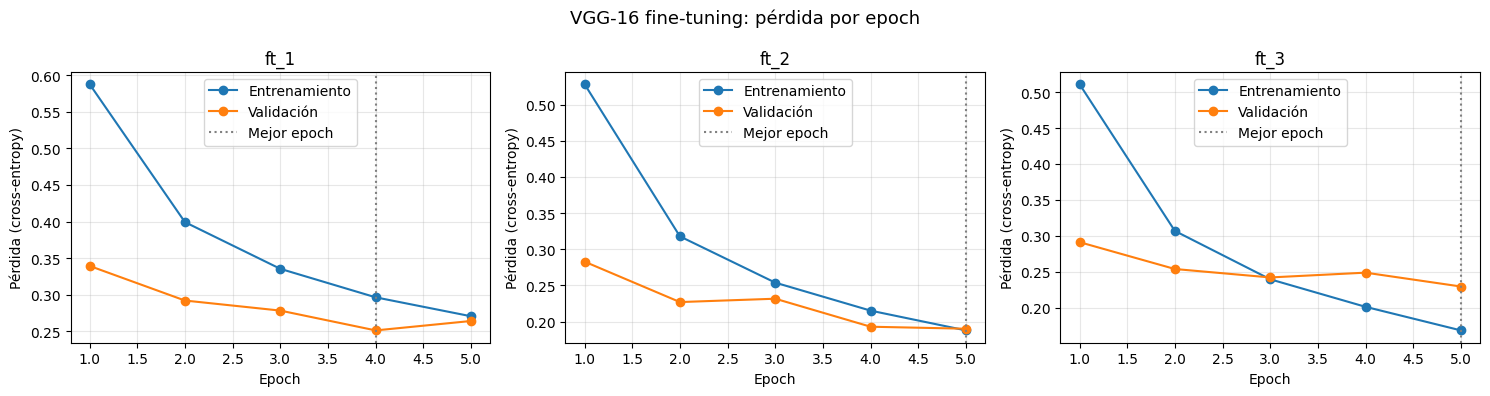

In [25]:
graficar_curvas([cfg["nombre"] for cfg in iteraciones_ft], "VGG-16 fine-tuning: pérdida por epoch")

## **Resumen de las iteraciones**

In [26]:
def tabla_iteraciones(nombres):
    """Construye la tabla con la configuración, métricas de validación y recursos de cada iteración."""
    filas = []
    for nombre in nombres:
        r = registro[nombre]
        config = {k: v for k, v in r["config"].items() if k != "nombre"}
        filas.append({
            "Iteración": nombre,
            "Modelo": r["tipo"],
            "Configuración": ", ".join(f"{k}={v}" for k, v in config.items()),
            "Parámetros totales": r["parametros_totales"],
            "Parámetros entrenables": r["parametros_entrenables"],
            "Mejor epoch": r["mejor_epoch"],
            "Epochs": r["epochs_ejecutadas"],
            "Accuracy": round(r["accuracy_val"], 4),
            "Precision": round(r["precision_val"], 4),
            "Recall": round(r["recall_val"], 4),
            "F1": round(r["f1_val"], 4),
            "Tiempo por epoch (s)": round(r["tiempo_promedio_epoch"], 1),
            "Tiempo total (min)": round(r["tiempo_total"] / 60, 2),
            "Memoria pico (MB)": round(r["memoria_pico_mb"], 1),
        })
    return pd.DataFrame(filas)


todas_las_iteraciones = [cfg["nombre"] for cfg in iteraciones_cnn + iteraciones_fe + iteraciones_ft]
tabla_iteraciones(todas_las_iteraciones)

,Iteración,Modelo,Configuración,Parámetros totales,Parámetros entrenables,Mejor epoch,Epochs,Accuracy,Precision,Recall,F1,Tiempo por epoch (s),Tiempo total (min),Memoria pico (MB)
0,cnn_1,CNN desde cero,"filtros=[32, 64, 128], dropout=0.3, lr=0.001, ...",815018,815018,11,14,0.8252,0.8260,0.8252,0.8229,12.3,3.11,131.7
1,cnn_2,CNN desde cero,"filtros=[64, 128, 256], dropout=0.3, lr=0.001,...",2198602,2198602,17,20,0.8648,0.8688,0.8648,0.8645,27.3,9.39,269.3
2,cnn_3,CNN desde cero,"filtros=[64, 128, 256], dropout=0.5, lr=0.001,...",2198602,2198602,15,18,0.8482,0.8542,0.8482,0.8487,28.1,8.70,269.3
3,fe_1,VGG-16 feature extractor,"lr=0.001, weight_decay=0.0, capas_congeladas=f...",134301514,119586826,5,8,0.8828,0.8857,0.8828,0.8833,72.4,14.85,1396.8
4,fe_2,VGG-16 feature extractor,"lr=0.0001, weight_decay=0.0, capas_congeladas=...",134301514,119586826,3,6,0.8904,0.8911,0.8904,0.8901,61.8,10.93,1396.8
5,fe_3,VGG-16 feature extractor,"lr=0.0001, weight_decay=0.0005, capas_congelad...",134301514,119586826,3,6,0.8922,0.8955,0.8922,0.8925,66.7,11.20,1396.8
6,ft_1,VGG-16 fine-tuning,"bloques_descongelados=1, lr_backbone=1e-05, lr...",134301514,126666250,4,5,0.9152,0.9166,0.9152,0.9154,256.4,23.50,1591.0
7,ft_2,VGG-16 fine-tuning,"bloques_descongelados=2, lr_backbone=1e-05, lr...",134301514,132566026,5,5,0.9370,0.9374,0.9370,0.9369,349.8,31.07,1860.5
8,ft_3,VGG-16 fine-tuning,"bloques_descongelados=1, lr_backbone=0.0001, l...",134301514,126666250,5,5,0.9264,0.9276,0.9264,0.9265,225.9,20.59,1591.0


## **Evaluación final sobre el conjunto de test**

In [27]:
def construir_modelo(nombre):
    """Reconstruye la arquitectura de una iteración a partir de su configuración en el registro."""
    tipo, cfg = registro[nombre]["tipo"], registro[nombre]["config"]
    if tipo.startswith("CNN"):
        return crear_cnn(cfg["filtros"], cfg["dropout"])
    if tipo.startswith("VGG-16 feature extractor"):
        return crear_cabeza_fe()
    return crear_vgg(cfg["bloques_descongelados"])


def construir_optimizador(nombre, modelo):
    """Reconstruye el optimizador de una iteración a partir de su configuración en el registro."""
    tipo, cfg = registro[nombre]["tipo"], registro[nombre]["config"]
    if tipo.startswith("VGG-16 fine-tuning"):
        return optimizador_fine_tuning(modelo, cfg["lr_backbone"], cfg["lr_clasificador"])
    return torch.optim.AdamW(modelo.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])


def cargar_modelo_final(nombre):
    """Carga los mejores pesos de una iteración como un modelo completo que recibe imágenes."""
    modelo = construir_modelo(nombre)
    modelo.load_state_dict(torch.load(registro[nombre]["ruta_pesos"], map_location="cpu"))
    # El feature extractor se entrenó sobre features, por lo que su clasificador se coloca de nuevo en VGG-16
    if registro[nombre]["tipo"].startswith("VGG-16 feature extractor"):
        vgg = crear_vgg(bloques_descongelados=0)
        vgg.classifier = modelo[2]
        modelo = vgg
    return modelo.to(DEVICE)


loader_test_cnn = DataLoader(test_cnn, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
loader_test_vgg = DataLoader(test_vgg, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

RUTA_TEST = DIR_RESULTADOS / "resultados_test.json"
resultados_test = json.loads(RUTA_TEST.read_text()) if RUTA_TEST.exists() else {}


def evaluar_en_test(nombre):
    """Evalúa una iteración una única vez sobre test y guarda sus métricas y su matriz de confusión."""
    if nombre in resultados_test:
        print(f"{nombre} ya fue evaluada sobre test, se reutilizan sus resultados")
        return resultados_test[nombre]

    liberar_memoria()
    modelo = cargar_modelo_final(nombre)
    loader = loader_test_cnn if registro[nombre]["tipo"].startswith("CNN") else loader_test_vgg
    metricas, reales, predichas = evaluar(modelo, loader)
    resultados_test[nombre] = {**metricas, "matriz_confusion": confusion_matrix(reales, predichas).tolist()}
    RUTA_TEST.write_text(json.dumps(resultados_test, indent=2))

    del modelo
    liberar_memoria()
    return resultados_test[nombre]


def mejor_iteracion(iteraciones):
    """Retorna la iteración con el mayor F1-score macro de validación."""
    return max((cfg["nombre"] for cfg in iteraciones), key=lambda nombre: registro[nombre]["f1_val"])


MEJORES = {
    "CNN desde cero": mejor_iteracion(iteraciones_cnn),
    "VGG-16 feature extractor": mejor_iteracion(iteraciones_fe),
    "VGG-16 fine-tuning": mejor_iteracion(iteraciones_ft),
}

filas = []
for modelo, nombre in MEJORES.items():
    metricas = evaluar_en_test(nombre)
    filas.append({
        "Modelo": modelo,
        "Iteración": nombre,
        "F1 validación": round(registro[nombre]["f1_val"], 4),
        "Accuracy test": round(metricas["accuracy"], 4),
        "Precision test": round(metricas["precision"], 4),
        "Recall test": round(metricas["recall"], 4),
        "F1 test": round(metricas["f1"], 4),
    })

pd.DataFrame(filas)

Python(31315) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31318) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31335) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31338) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31447) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31450) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31463) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31466) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31697) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31700) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31705) Malloc

,Modelo,Iteración,F1 validación,Accuracy test,Precision test,Recall test,F1 test
0,CNN desde cero,cnn_2,0.8645,0.8600,0.8624,0.8600,0.8589
1,VGG-16 feature extractor,fe_3,0.8925,0.8863,0.8890,0.8863,0.8866
2,VGG-16 fine-tuning,ft_2,0.9369,0.9280,0.9281,0.9280,0.9279


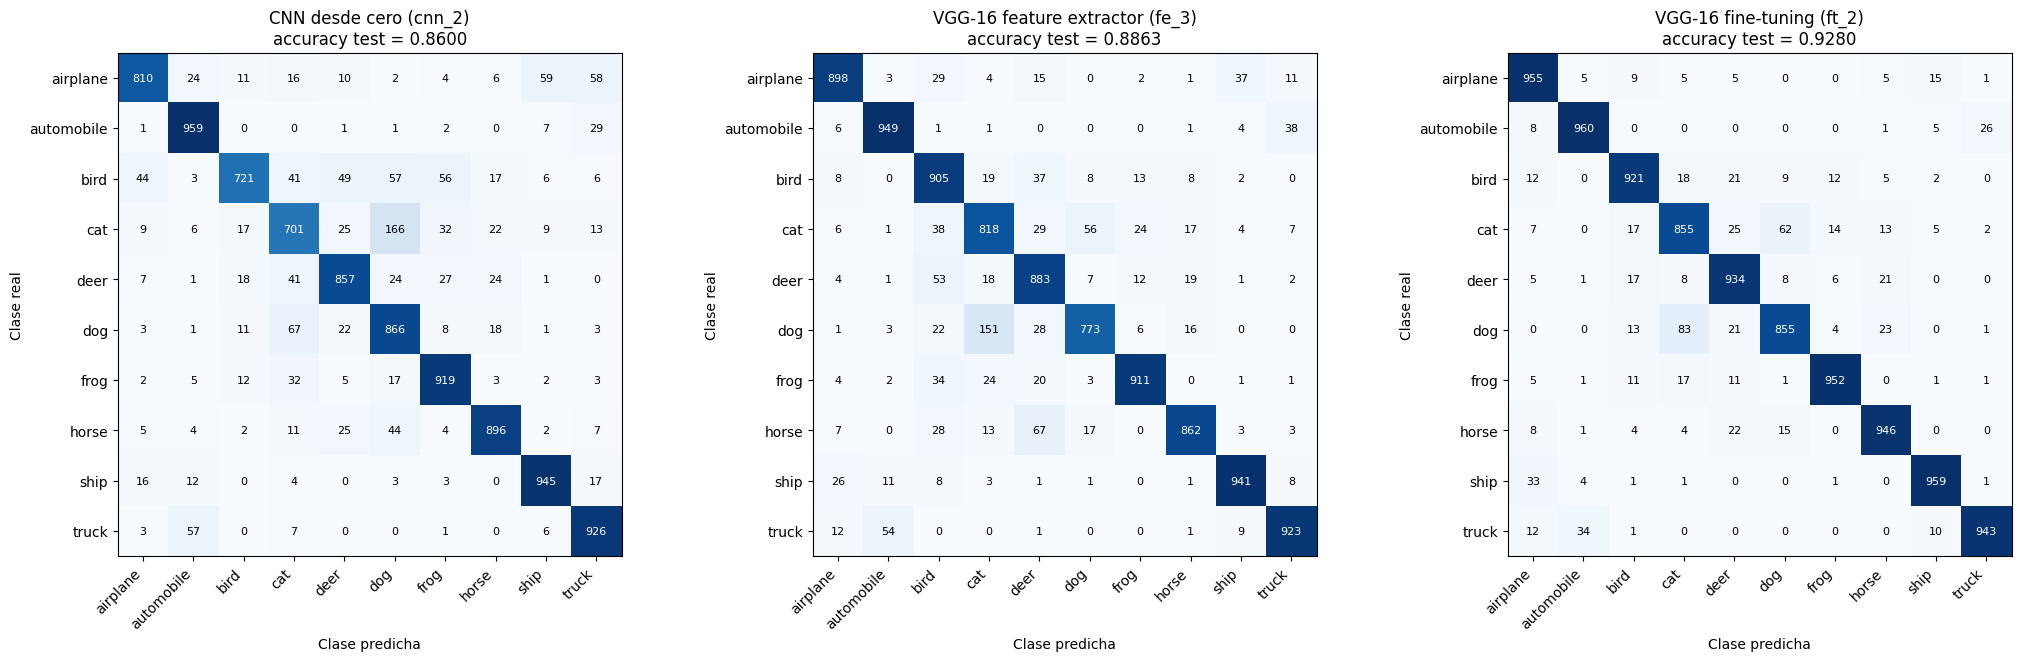

In [28]:
def graficar_matrices_confusion(nombres, titulos):
    """Grafica la matriz de confusión sobre test de cada iteración."""
    fig, axes = plt.subplots(1, len(nombres), figsize=(7 * len(nombres), 6.5))
    for ax, nombre, titulo in zip(np.atleast_1d(axes), nombres, titulos):
        matriz = np.array(resultados_test[nombre]["matriz_confusion"])
        ax.imshow(matriz, cmap="Blues")
        for i in range(len(CLASES)):
            for j in range(len(CLASES)):
                color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
                ax.text(j, i, matriz[i, j], ha="center", va="center", fontsize=8, color=color)
        ax.set_xticks(range(len(CLASES)))
        ax.set_xticklabels(CLASES, rotation=45, ha="right")
        ax.set_yticks(range(len(CLASES)))
        ax.set_yticklabels(CLASES)
        ax.set_xlabel("Clase predicha")
        ax.set_ylabel("Clase real")
        ax.set_title(f"{titulo} ({nombre})\naccuracy test = {resultados_test[nombre]['accuracy']:.4f}")
    plt.tight_layout()
    plt.show()


graficar_matrices_confusion(list(MEJORES.values()), list(MEJORES.keys()))

In [29]:
def principales_confusiones(nombre, n=5):
    """Retorna los pares (clase real, clase predicha) con más errores en test."""
    matriz = np.array(resultados_test[nombre]["matriz_confusion"])
    np.fill_diagonal(matriz, 0)
    pares = [(CLASES[i], CLASES[j], matriz[i, j]) for i in range(len(CLASES)) for j in range(len(CLASES))]
    pares = sorted(pares, key=lambda par: par[2], reverse=True)[:n]
    return [f"{real} -> {predicha} ({errores})" for real, predicha, errores in pares]


pd.DataFrame({modelo: principales_confusiones(nombre) for modelo, nombre in MEJORES.items()},
             index=[f"Top {i}" for i in range(1, 6)])

,CNN desde cero,VGG-16 feature extractor,VGG-16 fine-tuning
Top 1,cat -> dog (166),dog -> cat (151),dog -> cat (83)
Top 2,dog -> cat (67),horse -> deer (67),cat -> dog (62)
Top 3,airplane -> ship (59),cat -> dog (56),truck -> automobile (34)
Top 4,airplane -> truck (58),truck -> automobile (54),ship -> airplane (33)
Top 5,bird -> dog (57),deer -> bird (53),automobile -> truck (26)


## **Sinopsis de los resultados**

La CNN desde cero alcanzó su mejor desempeño al duplicar el número de filtros (`cnn_2`), con un F1-score de 0.8645 en validación, mientras que aumentar la regularización lo redujo, lo cual indica que a la red le faltaba capacidad más que presentar overfitting. Por otro lado, VGG-16 como feature extractor superó a la CNN desde la primera epoch gracias a las features aprendidas en ImageNet, y obtuvo su mejor resultado con un learning rate de 1e-4 y weight decay (`fe_3`, F1 de 0.8925); no obstante, al entrenar 119.6 millones de parámetros sin augmentation presentó overfitting a partir de la tercera epoch, el cual fue contenido por el early stopping. Finalmente, el fine-tuning obtuvo el mejor desempeño al descongelar los bloques 4 y 5 (`ft_2`, F1 de 0.9369), y cabe mencionar que aumentar el learning rate del backbone a 1e-4 mejoró el resultado frente a 1e-5 sin mostrar señales de catastrophic forgetting.

Sobre el conjunto de test, los tres modelos mantuvieron un desempeño cercano al de validación, con un F1-score de 0.8589 para la CNN, 0.8866 para el feature extractor y 0.9279 para el fine-tuning. Asimismo, las matrices de confusión confirmaron lo que se esperaba al visualizar los datos, ya que el par más confundido en los tres modelos fue gato y perro, seguido de otros pares que también se habían anticipado, como camión y automóvil, avión y barco, y caballo y venado. Sin embargo, el fine-tuning redujo considerablemente la confusión entre gato y perro, pasando de 166 gatos clasificados como perros en la CNN a 62.

## **Experimento adicional: efecto de la cantidad de datos**

In [30]:
FRACCION_DATOS = 0.10

# Se toma el 10 % del conjunto de entrenamiento manteniendo el balance entre clases
indices_train_10, _ = train_test_split(
    indices_train,
    train_size=FRACCION_DATOS,
    stratify=etiquetas[indices_train],
    random_state=SEED,
)

print(f"Imágenes de entrenamiento con el 10 %: {len(indices_train_10)}")
pd.Series(etiquetas[indices_train_10]).map(lambda i: CLASES[i]).value_counts().reindex(CLASES).to_frame("Imágenes (train 10 %)")

Imágenes de entrenamiento con el 10 %: 4500


,Imágenes (train 10 %)
airplane,450
automobile,450
bird,450
cat,450
deer,450
dog,450
frog,450
horse,450
ship,450
truck,450


In [31]:
def entrenar_con_fraccion(nombre_base, loader_train, loader_val, max_epochs, paciencia, tiempo_adicional=0.0):
    """Reentrena la mejor configuración de un modelo con el 10 % de los datos de entrenamiento."""
    r = registro[nombre_base]
    return ejecutar_iteracion(
        nombre=f"{nombre_base}_10pct",
        tipo=f"{r['tipo']} (10 % de los datos)",
        config=r["config"],
        crear_modelo=lambda: construir_modelo(nombre_base),
        crear_optimizador=lambda m: construir_optimizador(nombre_base, m),
        loader_train=loader_train,
        loader_val=loader_val,
        max_epochs=max_epochs,
        paciencia=paciencia,
        parametros=(r["parametros_totales"], r["parametros_entrenables"]),
        tiempo_adicional=tiempo_adicional,
    )


# CNN desde cero: mismo pipeline con augmentation, pero solo con el 10 % de las imágenes
loader_train_cnn_10, loader_val_cnn_10 = crear_loaders(Subset(train_cnn.dataset, indices_train_10), val_cnn)
entrenar_con_fraccion(MEJORES["CNN desde cero"], loader_train_cnn_10, loader_val_cnn_10, MAX_EPOCHS_CNN, PACIENCIA_CNN)
print()

# Feature extractor: se extraen las features únicamente del 10 % de las imágenes
vgg_base = crear_vgg(bloques_descongelados=0).to(DEVICE)
sincronizar()
inicio = time.perf_counter()
features_train_10 = extraer_features(vgg_base.features, Subset(train_vgg_sin_augmentation.dataset, indices_train_10))
sincronizar()
tiempo_extraccion_10 = time.perf_counter() - inicio
if "features_val" not in globals():
    features_val = extraer_features(vgg_base.features, val_vgg)
del vgg_base
liberar_memoria()

loader_train_fe_10, loader_val_fe_10 = crear_loaders(features_train_10, features_val, num_workers=0)
entrenar_con_fraccion(MEJORES["VGG-16 feature extractor"], loader_train_fe_10, loader_val_fe_10,
                      MAX_EPOCHS_FE, PACIENCIA_FE, tiempo_adicional=tiempo_extraccion_10)
print()

# Fine-tuning: mismo pipeline con augmentation, pero solo con el 10 % de las imágenes
loader_train_ft_10, loader_val_ft_10 = crear_loaders(Subset(train_vgg.dataset, indices_train_10), val_vgg)
entrenar_con_fraccion(MEJORES["VGG-16 fine-tuning"], loader_train_ft_10, loader_val_ft_10, MAX_EPOCHS_FT, PACIENCIA_FT);

Iteración cnn_2_10pct (CNN desde cero (10 % de los datos)): {'nombre': 'cnn_2', 'filtros': [64, 128, 256], 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0}


Python(31930) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31936) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31943) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31957) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31982) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31985) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31988) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32003) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 1/20: loss train 2.1880, loss val 1.8972, accuracy val 0.2870, f1 val 0.2678, tiempo 11.5 s
Epoch 2/20: loss train 1.8694, loss val 1.6814, accuracy val 0.3838, f1 val 0.3660, tiempo 2.6 s
Epoch 3/20: loss train 1.7477, loss val 1.7040, accuracy val 0.3786, f1 val 0.3571, tiempo 2.5 s
Epoch 4/20: loss train 1.6711, loss val 1.7992, accuracy val 0.3532, f1 val 0.3252, tiempo 2.6 s
Epoch 5/20: loss train 1.6102, loss val 1.4339, accuracy val 0.4724, f1 val 0.4627, tiempo 2.6 s
Epoch 6/20: loss train 1.5277, loss val 1.5692, accuracy val 0.4414, f1 val 0.4184, tiempo 2.6 s
Epoch 7/20: loss train 1.4505, loss val 1.3993, accuracy val 0.5058, f1 val 0.4848, tiempo 2.6 s
Epoch 8/20: loss train 1.4281, loss val 1.2973, accuracy val 0.5174, f1 val 0.5088, tiempo 2.6 s
Epoch 9/20: loss train 1.3481, loss val 1.4925, accuracy val 0.4694, f1 val 0.4346, tiempo 2.6 s
Epoch 10/20: loss train 1.3240, loss val 1.2094, accuracy val 0.5518, f1 val 0.5322, tiempo 2.6 s
Epoch 11/20: loss train 1.23

Python(32342) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32346) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32360) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32364) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Iteración fe_3_10pct (VGG-16 feature extractor (10 % de los datos)): {'nombre': 'fe_3', 'lr': 0.0001, 'weight_decay': 0.0005, 'capas_congeladas': 'features completo (bloques 1 a 5)'}
Epoch 1/15: loss train 1.0136, loss val 0.5310, accuracy val 0.8168, f1 val 0.8178, tiempo 6.7 s
Epoch 2/15: loss train 0.4121, loss val 0.4580, accuracy val 0.8424, f1 val 0.8424, tiempo 6.4 s
Epoch 3/15: loss train 0.2467, loss val 0.4765, accuracy val 0.8416, f1 val 0.8422, tiempo 6.0 s
Epoch 4/15: loss train 0.1611, loss val 0.4744, accuracy val 0.8488, f1 val 0.8484, tiempo 5.7 s
Epoch 5/15: loss train 0.0859, loss val 0.4880, accuracy val 0.8486, f1 val 0.8479, tiempo 5.7 s
Early stopping: la pérdida de validación no mejoró en 3 epochs

Iteración ft_2_10pct (VGG-16 fine-tuning (10 % de los datos)): {'nombre': 'ft_2', 'bloques_descongelados': 2, 'lr_backbone': 1e-05, 'lr_clasificador': 0.0001, 'capas_congeladas': 'bloques 1 a 3'}


Python(32680) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32683) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32696) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32697) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32823) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32841) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(32844) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 1/5: loss train 1.0876, loss val 0.5046, accuracy val 0.8240, f1 val 0.8236, tiempo 43.5 s
Epoch 2/5: loss train 0.5246, loss val 0.4353, accuracy val 0.8478, f1 val 0.8473, tiempo 35.4 s
Epoch 3/5: loss train 0.4192, loss val 0.3855, accuracy val 0.8688, f1 val 0.8689, tiempo 35.1 s
Epoch 4/5: loss train 0.3462, loss val 0.3764, accuracy val 0.8700, f1 val 0.8693, tiempo 35.6 s
Epoch 5/5: loss train 0.2819, loss val 0.3946, accuracy val 0.8694, f1 val 0.8691, tiempo 35.3 s


In [32]:
filas = []
for modelo, nombre in MEJORES.items():
    test_100 = resultados_test[nombre]
    test_10 = evaluar_en_test(f"{nombre}_10pct")
    filas.append({
        "Modelo": modelo,
        "Accuracy 100 %": round(test_100["accuracy"], 4),
        "Accuracy 10 %": round(test_10["accuracy"], 4),
        "F1 100 %": round(test_100["f1"], 4),
        "F1 10 %": round(test_10["f1"], 4),
        "Caída de F1 (puntos)": round((test_100["f1"] - test_10["f1"]) * 100, 2),
        "Caída relativa de F1 (%)": round((test_100["f1"] - test_10["f1"]) / test_100["f1"] * 100, 2),
    })

comparacion_datos = pd.DataFrame(filas)
comparacion_datos

Python(34070) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34074) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34087) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34088) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34227) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34230) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34235) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34241) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34457) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34458) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34461) Malloc

,Modelo,Accuracy 100 %,Accuracy 10 %,F1 100 %,F1 10 %,Caída de F1 (puntos),Caída relativa de F1 (%)
0,CNN desde cero,0.8600,0.6154,0.8589,0.6115,24.74,28.80
1,VGG-16 feature extractor,0.8863,0.8318,0.8866,0.8320,5.46,6.15
2,VGG-16 fine-tuning,0.9280,0.8613,0.9279,0.8606,6.73,7.25


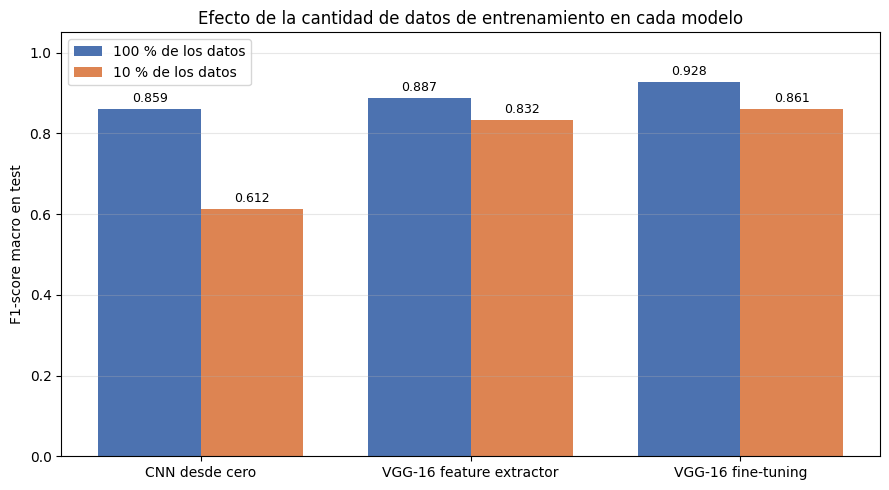

In [33]:
x = np.arange(len(comparacion_datos))
ancho = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
barras_100 = ax.bar(x - ancho / 2, comparacion_datos["F1 100 %"], ancho, label="100 % de los datos", color="#4C72B0")
barras_10 = ax.bar(x + ancho / 2, comparacion_datos["F1 10 %"], ancho, label="10 % de los datos", color="#DD8452")

# Se etiqueta cada barra con su valor para poder comparar las magnitudes
for barras in (barras_100, barras_10):
    for barra in barras:
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.01,
                f"{barra.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparacion_datos["Modelo"])
ax.set_ylabel("F1-score macro en test")
ax.set_ylim(0, 1.05)
ax.set_title("Efecto de la cantidad de datos de entrenamiento en cada modelo")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
# **5. Comparación de rendimiento y recursos**

**Parámetros totales y parámetros entrenables.**

La CNN desde cero cuenta con 2,198,602 parámetros, todos entrenables, mientras que ambos modelos basados en VGG-16 cuentan con 134,301,514 parámetros totales, de los cuales se entrenan 119,586,826 en el feature extractor y 132,566,026 en el fine-tuning. Esta diferencia se debe a la arquitectura, ya que VGG-16 fue diseñada para clasificar 1,000 categorías de ImageNet, y únicamente la primera capa densa de su clasificador concentra alrededor de 103 millones de parámetros. Es por esto que, aunque en el feature extractor se congelan todos los bloques convolucionales, se sigue entrenando el 89 % del modelo. La gran diferencia es que la CNN aprende todos sus parámetros desde cero, mientras que en los modelos basados en VGG-16 se parte de los pesos aprendidos en ImageNet, lo que permite aprovechar un modelo de este tamaño sin tener que entrenarlo por completo.

In [44]:
tabla_parametros = pd.DataFrame([{
    "Modelo": modelo,
    "Parámetros totales": registro[nombre]["parametros_totales"],
    "Parámetros entrenables": registro[nombre]["parametros_entrenables"],
    "% entrenable": round(registro[nombre]["parametros_entrenables"] / registro[nombre]["parametros_totales"] * 100, 2),
} for modelo, nombre in MEJORES.items()])

tabla_parametros

,Modelo,Parámetros totales,Parámetros entrenables,% entrenable
0,CNN desde cero,2198602,2198602,100.00
1,VGG-16 feature extractor,134301514,119586826,89.04
2,VGG-16 fine-tuning,134301514,132566026,98.71


**Costo de inferencia: MACs o FLOPs por imagen (forward pass) y latencia promedio por imagen en GPU.**

La CNN desde cero requiere 0.154 GMACs (0.31 GFLOPs) por imagen, mientras que ambos modelos basados en VGG-16 requieren 5.135 GMACs (10.27 GFLOPs), es decir, alrededor de 33 veces más, ya que comparten la misma arquitectura y trabajan con imágenes de 128x128. Esto se refleja en la latencia, la cual fue de 2.3 ms por imagen para la CNN y de entre 14 y 18 ms para VGG-16. Cabe mencionar que la diferencia entre ambos modelos VGG-16 corresponde a variación en la medición, pues realizan exactamente las mismas operaciones.

In [45]:
def macs(modulo, forma_entrada):
    """MACs de un forward pass de un módulo, calculados en CPU con torchinfo."""
    return summary(modulo, input_size=forma_entrada, device="cpu", verbose=0).total_mult_adds


def medir_latencia(modelo, forma_entrada, repeticiones=200, calentamiento=30):
    """Latencia promedio en milisegundos de un forward pass con una sola imagen en la GPU."""
    modelo.eval()
    x = torch.randn(1, *forma_entrada, device=DEVICE)
    tiempos = []
    with torch.no_grad():
        for i in range(calentamiento + repeticiones):
            sincronizar()
            inicio = time.perf_counter()
            modelo(x)
            sincronizar()
            if i >= calentamiento:
                tiempos.append(time.perf_counter() - inicio)
    return np.mean(tiempos) * 1000


FORMA_ENTRADA = {
    "CNN desde cero": (3, 32, 32),
    "VGG-16 feature extractor": (3, RESOLUCION_VGG, RESOLUCION_VGG),
    "VGG-16 fine-tuning": (3, RESOLUCION_VGG, RESOLUCION_VGG),
}

filas = []
for modelo, nombre in MEJORES.items():
    liberar_memoria()
    red = cargar_modelo_final(nombre)
    latencia = medir_latencia(red, FORMA_ENTRADA[modelo])
    macs_imagen = macs(red, (1, *FORMA_ENTRADA[modelo]))
    filas.append({
        "Modelo": modelo,
        "Resolución": f"{FORMA_ENTRADA[modelo][1]}x{FORMA_ENTRADA[modelo][2]}",
        "GMACs por imagen": round(macs_imagen / 1e9, 3),
        "GFLOPs por imagen": round(2 * macs_imagen / 1e9, 3),
        "Latencia por imagen (ms)": round(latencia, 2),
    })
    del red

tabla_inferencia = pd.DataFrame(filas)
tabla_inferencia

,Modelo,Resolución,GMACs por imagen,GFLOPs por imagen,Latencia por imagen (ms)
0,CNN desde cero,32x32,0.154,0.308,1.96
1,VGG-16 feature extractor,128x128,5.135,10.270,13.43
2,VGG-16 fine-tuning,128x128,5.135,10.270,9.99


**Costo de entrenamiento: tiempo por epoch, número de epochs hasta alcanzar la mejor métrica de validación, tiempo total y memoria pico de GPU.**

La CNN tomó 27.3 s por epoch y necesitó 17 epochs para alcanzar su mejor métrica, con un tiempo total de 9.4 min y 269 MB de memoria pico. El feature extractor tomó 66.7 s por epoch y alcanzó su mejor métrica en apenas 3 epochs, con un tiempo total de 11.2 min que incluye la extracción de features, y 1,397 MB de memoria pico. Por último, el fine-tuning fue el más costoso, con 349.8 s por epoch, 5 epochs, 31.1 min en total y 1,861 MB de memoria pico, ya que en cada imagen debe recorrer VGG-16 completa y además propagar el gradiente por los bloques 4 y 5.

In [46]:
tabla_entrenamiento = pd.DataFrame([{
    "Modelo": modelo,
    "Tiempo por epoch (s)": round(registro[nombre]["tiempo_promedio_epoch"], 1),
    "Epochs hasta la mejor métrica": registro[nombre]["mejor_epoch"],
    "Epochs ejecutadas": registro[nombre]["epochs_ejecutadas"],
    "Tiempo total (min)": round(registro[nombre]["tiempo_total"] / 60, 2),
    "Memoria pico (MB)": round(registro[nombre]["memoria_pico_mb"], 1),
} for modelo, nombre in MEJORES.items()])

tabla_entrenamiento

,Modelo,Tiempo por epoch (s),Epochs hasta la mejor métrica,Epochs ejecutadas,Tiempo total (min),Memoria pico (MB)
0,CNN desde cero,27.3,17,20,9.39,269.3
1,VGG-16 feature extractor,66.7,3,6,11.20,1396.8
2,VGG-16 fine-tuning,349.8,5,5,31.07,1860.5


**Estimación del cómputo total de entrenamiento (en FLOPs) a partir del costo por imagen, el número de imágenes y el número de epochs, considerando qué partes de la red realizan backward pass en cada estrategia.**

Se estimó el cómputo como 2 x imágenes x epochs x (MACs del forward + 2 x MACs de las capas con gradiente), asumiendo que el backward cuesta el doble del forward en las capas que se entrenan y que no existe en las capas congeladas. Bajo este criterio, la CNN requirió 0.83 PFLOPs, pues realiza el backward en toda la red. El feature extractor requirió 0.65 PFLOPs, ya que el backbone se recorrió una sola vez para extraer las features y en cada epoch solo se entrenó el clasificador. El fine-tuning requirió 4.19 PFLOPs, alrededor de 5 veces más que la CNN, porque en cada epoch recorre VGG-16 completa y realiza el backward desde el bloque 4. Cabe mencionar que la estimación no incluye las pasadas de validación.

In [47]:
# MACs por imagen de cada parte de VGG-16 a la resolución utilizada
vgg_cpu = crear_vgg(bloques_descongelados=0)
lado = RESOLUCION_VGG
MACS_VGG = {
    "bloques 1 a 3": macs(vgg_cpu.features[:17], (1, 3, lado, lado)),
    "bloque 4": macs(vgg_cpu.features[17:24], (1, 256, lado // 8, lado // 8)),
    "bloque 5": macs(vgg_cpu.features[24:], (1, 512, lado // 16, lado // 16)),
    "clasificador": macs(nn.Sequential(vgg_cpu.avgpool, nn.Flatten(), vgg_cpu.classifier), (1, 512, lado // 32, lado // 32)),
}
del vgg_cpu

N_IMAGENES_TRAIN = len(indices_train)


def estimar_flops_entrenamiento(nombre):
    """Estima los FLOPs de entrenamiento, asumiendo que el backward cuesta el doble del forward de las capas con gradiente."""
    r = registro[nombre]
    cfg, epochs = r["config"], r["epochs_ejecutadas"]
    macs_extraccion = 0

    if r["tipo"].startswith("CNN"):
        macs_forward = macs(crear_cnn(cfg["filtros"], cfg["dropout"]), (1, 3, 32, 32))
        macs_con_gradiente = macs_forward
    elif r["tipo"].startswith("VGG-16 feature extractor"):
        # El backbone solo se recorre una vez para extraer las features; en cada epoch solo trabaja el clasificador
        macs_extraccion = N_IMAGENES_TRAIN * (MACS_VGG["bloques 1 a 3"] + MACS_VGG["bloque 4"] + MACS_VGG["bloque 5"])
        macs_forward = MACS_VGG["clasificador"]
        macs_con_gradiente = MACS_VGG["clasificador"]
    else:
        macs_forward = sum(MACS_VGG.values())
        macs_con_gradiente = MACS_VGG["clasificador"] + MACS_VGG["bloque 5"]
        if cfg["bloques_descongelados"] == 2:
            macs_con_gradiente += MACS_VGG["bloque 4"]

    macs_por_imagen = macs_forward + 2 * macs_con_gradiente
    macs_totales = N_IMAGENES_TRAIN * epochs * macs_por_imagen + macs_extraccion
    return {
        "GMACs forward por imagen (entrenamiento)": round(macs_forward / 1e9, 3),
        "GMACs forward + backward por imagen (entrenamiento)": round(macs_por_imagen / 1e9, 3),
        "Epochs": epochs,
        "PFLOPs de entrenamiento": round(2 * macs_totales / 1e15, 3),
    }


print("GMACs por imagen de cada parte de VGG-16:")
for parte, valor in MACS_VGG.items():
    print(f"{parte}: {valor / 1e9:.3f}")

tabla_flops = pd.DataFrame([{"Modelo": modelo, **estimar_flops_entrenamiento(nombre)} for modelo, nombre in MEJORES.items()])
tabla_flops

GMACs por imagen de cada parte de VGG-16:
bloques 1 a 3: 3.052
bloque 4: 1.510
bloque 5: 0.453
clasificador: 0.120


,Modelo,GMACs forward por imagen (entrenamiento),GMACs forward + backward por imagen (entrenamiento),Epochs,PFLOPs de entrenamiento
0,CNN desde cero,0.154,0.462,20,0.832
1,VGG-16 feature extractor,0.120,0.359,6,0.645
2,VGG-16 fine-tuning,5.135,9.301,5,4.186


**Desempeño sobre el conjunto de test (accuracy, precision, recall, F1-score).**

El fine-tuning obtuvo el mejor desempeño, con un F1-score de 0.9279, seguido del feature extractor con 0.8866 y la CNN desde cero con 0.8589. Como se mencionó previamente, al estar el dataset perfectamente balanceado la accuracy es una medida confiable, y de hecho las cuatro métricas son prácticamente equivalentes en cada modelo, con diferencias menores a 0.004. El mejor resultado del fine-tuning tiene sentido, ya que no se comienza desde cero, sino que se parte de un modelo especializado en el reconocimiento de imágenes y se ajustan sus bloques superiores a CIFAR-10.

In [48]:
tabla_test = pd.DataFrame([{
    "Modelo": modelo,
    "Accuracy test": round(resultados_test[nombre]["accuracy"], 4),
    "Precision test": round(resultados_test[nombre]["precision"], 4),
    "Recall test": round(resultados_test[nombre]["recall"], 4),
    "F1 test": round(resultados_test[nombre]["f1"], 4),
} for modelo, nombre in MEJORES.items()])

tabla_test

,Modelo,Accuracy test,Precision test,Recall test,F1 test
0,CNN desde cero,0.8600,0.8624,0.8600,0.8589
1,VGG-16 feature extractor,0.8863,0.8890,0.8863,0.8866
2,VGG-16 fine-tuning,0.9280,0.9281,0.9280,0.9279


**Resultados del experimento de cantidad de datos (sección 4.1).**

Al reducir los datos de entrenamiento al 10 %, la CNN desde cero fue la más afectada, pues su F1-score cayó 24.74 puntos, de 0.8589 a 0.6115. En contraste, la caída fue mucho más leve en los modelos basados en VGG-16, de 5.46 puntos en el feature extractor y de 6.73 en el fine-tuning, lo cual probablemente se debe al headstart que ofrecen los pesos de ImageNet, ya que la mayor parte de lo que necesitan para reconocer imágenes ya fue aprendido.

In [49]:
tabla_datos = pd.DataFrame([{
    "Modelo": modelo,
    "F1 test 100 %": round(resultados_test[nombre]["f1"], 4),
    "F1 test 10 %": round(resultados_test[f"{nombre}_10pct"]["f1"], 4),
    "Caída de F1 (puntos)": round((resultados_test[nombre]["f1"] - resultados_test[f"{nombre}_10pct"]["f1"]) * 100, 2),
} for modelo, nombre in MEJORES.items()])

tabla_datos

,Modelo,F1 test 100 %,F1 test 10 %,Caída de F1 (puntos)
0,CNN desde cero,0.8589,0.6115,24.74
1,VGG-16 feature extractor,0.8866,0.8320,5.46
2,VGG-16 fine-tuning,0.9279,0.8606,6.73


**Tabla comparativa entre la CNN desde cero, VGG-16 como feature extractor y VGG-16 con fine-tuning.**

La tabla muestra que la CNN desde cero es la opción más ligera en prácticamente todos los aspectos, con 61 veces menos parámetros, 33 veces menos operaciones por imagen y la menor memoria, pero también la de menor desempeño y la más dependiente de la cantidad de datos. Por otro lado, los modelos basados en VGG-16 ofrecen buenos resultados desde el inicio: el feature extractor alcanza su mejor métrica en 3 epochs y con el menor cómputo de entrenamiento, mientras que el fine-tuning obtiene el mejor desempeño a cambio de alrededor de 5 veces el cómputo y 3.3 veces el tiempo de entrenamiento de la CNN.

In [50]:
tabla_comparativa = tabla_parametros
# Se quitan las columnas que se repiten entre tablas
for tabla in [tabla_inferencia, tabla_entrenamiento, tabla_flops.drop(columns=["Epochs"]), tabla_test,
              tabla_datos.drop(columns=["F1 test 100 %"])]:
    tabla_comparativa = tabla_comparativa.merge(tabla, on="Modelo")

tabla_comparativa.to_csv(DIR_RESULTADOS / "tabla_comparativa.csv", index=False)

# Se transpone para que cada modelo sea una columna y la tabla se pueda leer completa
tabla_comparativa.set_index("Modelo").T

Modelo,CNN desde cero,VGG-16 feature extractor,VGG-16 fine-tuning
Parámetros totales,2198602,134301514,134301514
Parámetros entrenables,2198602,119586826,132566026
% entrenable,100.0,89.04,98.71
Resolución,32x32,128x128,128x128
GMACs por imagen,0.154,5.135,5.135
GFLOPs por imagen,0.308,10.27,10.27
Latencia por imagen (ms),1.96,13.43,9.99
Tiempo por epoch (s),27.3,66.7,349.8
Epochs hasta la mejor métrica,17,3,5
Epochs ejecutadas,20,6,5


**Gráfica de accuracy de validación contra tiempo de entrenamiento acumulado.**

La gráfica muestra que la CNN desde cero comienza con una accuracy de validación de 0.55 y necesita varios minutos de entrenamiento para superar el 0.85, mientras que los modelos basados en VGG-16 inician por encima de 0.87 desde su primera epoch. No obstante, el feature extractor se estanca alrededor de 0.89, mientras que el fine-tuning continúa mejorando hasta alcanzar 0.937, aunque para ello requiere alrededor de 30 min de entrenamiento.

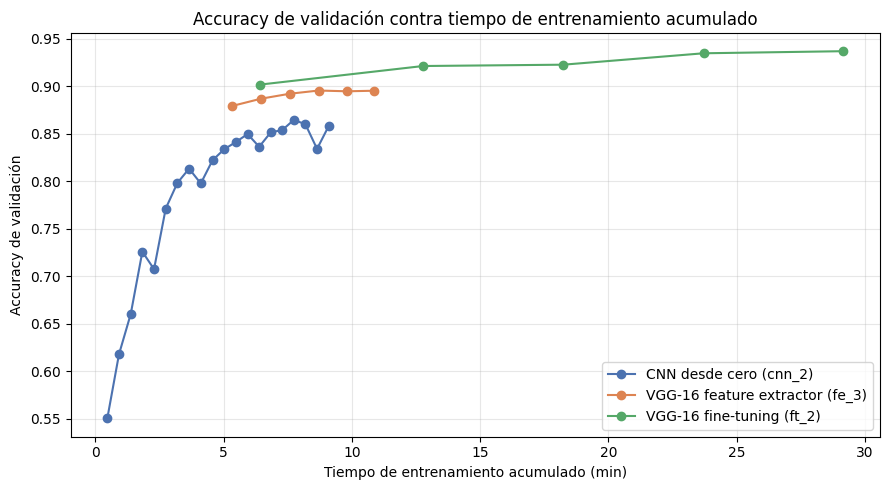

In [51]:
COLORES = {"CNN desde cero": "#4C72B0", "VGG-16 feature extractor": "#DD8452", "VGG-16 fine-tuning": "#55A868"}

fig, ax = plt.subplots(figsize=(9, 5))
for modelo, nombre in MEJORES.items():
    historial = registro[nombre]["historial"]
    # El feature extractor parte del tiempo que tomó extraer las features, ya que es parte de su entrenamiento
    inicio = TIEMPO_EXTRACCION if modelo == "VGG-16 feature extractor" else 0.0
    tiempo_acumulado = (inicio + np.cumsum(historial["tiempo_epoch"])) / 60
    ax.plot(tiempo_acumulado, historial["accuracy_val"], marker="o", color=COLORES[modelo], label=f"{modelo} ({nombre})")

ax.set_xlabel("Tiempo de entrenamiento acumulado (min)")
ax.set_ylabel("Accuracy de validación")
ax.set_title("Accuracy de validación contra tiempo de entrenamiento acumulado")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Gráfica de F1-score de test contra costo computacional.**

En ambos paneles se observa que un mayor costo computacional se traduce en un mejor desempeño, aunque con rendimientos decrecientes. En inferencia, pasar de la CNN a VGG-16 multiplica el costo por 33 y mejora el F1-score entre 2.8 y 6.9 puntos, según la estrategia. En entrenamiento, el feature extractor mejora a la CNN con menos cómputo, mientras que el fine-tuning obtiene 4.1 puntos adicionales a cambio de alrededor de 6.5 veces el cómputo del feature extractor.

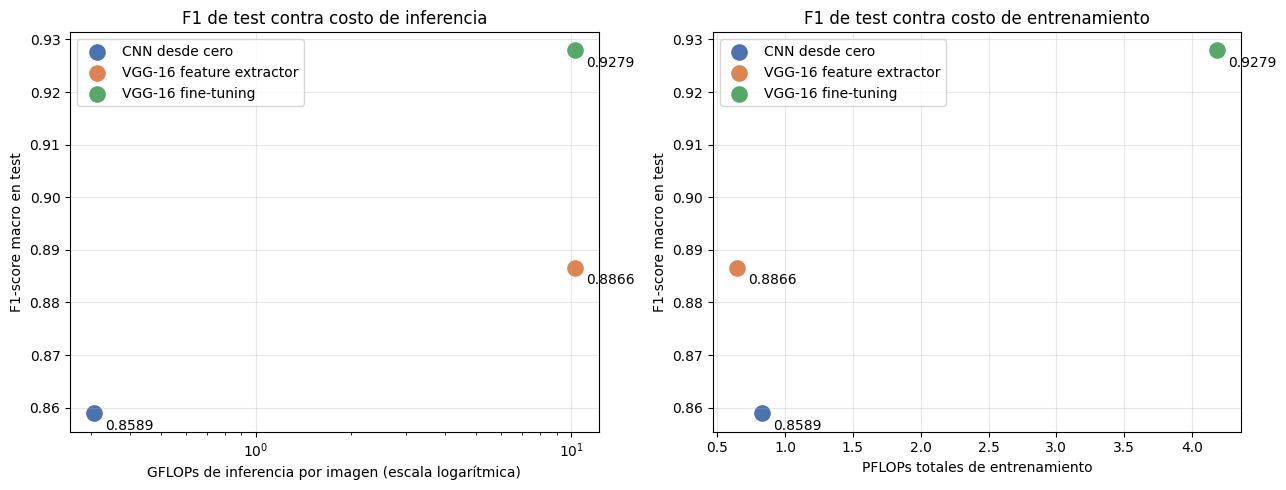

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for modelo in MEJORES:
    f1 = tabla_test.set_index("Modelo").loc[modelo, "F1 test"]
    gflops = tabla_inferencia.set_index("Modelo").loc[modelo, "GFLOPs por imagen"]
    pflops = tabla_flops.set_index("Modelo").loc[modelo, "PFLOPs de entrenamiento"]
    ax1.scatter(gflops, f1, s=120, color=COLORES[modelo], label=modelo)
    ax1.annotate(f"{f1:.4f}", (gflops, f1), textcoords="offset points", xytext=(8, -12))
    ax2.scatter(pflops, f1, s=120, color=COLORES[modelo], label=modelo)
    ax2.annotate(f"{f1:.4f}", (pflops, f1), textcoords="offset points", xytext=(8, -12))

ax1.set_xscale("log")
ax1.set_xlabel("GFLOPs de inferencia por imagen (escala logarítmica)")
ax1.set_title("F1 de test contra costo de inferencia")
ax2.set_xlabel("PFLOPs totales de entrenamiento")
ax2.set_title("F1 de test contra costo de entrenamiento")
for ax in (ax1, ax2):
    ax.set_ylabel("F1-score macro en test")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

**Hardware utilizado.**

Los experimentos se ejecutaron en una MacBook con procesador Apple M4 y 16 GB de memoria unificada, utilizando la GPU integrada mediante MPS. A nivel de hardware se tuvieron ciertas dificultades, ya que al no contar con una cantidad amplia de memoria, en repetidas ocasiones se presentaron avisos de memoria saturada, y no solo por la RAM, sino porque incluso la memoria virtual terminó llenándose debido al poco espacio libre en disco. A esto se suma que MPS no cuenta con una tarjeta gráfica dedicada con VRAM propia, pues la GPU comparte la memoria con el resto del sistema, lo cual impactó considerablemente en los tiempos de entrenamiento. Asimismo, MPS no ofrece un equivalente a `torch.cuda.max_memory_allocated()`, por lo que la memoria pico se midió con `torch.mps.current_allocated_memory()` después de cada forward, y no soporta el `AdaptiveAvgPool2d` de VGG-16 con mapas de 4x4, por lo que esa capa se ejecutó en CPU.

In [53]:
import platform
import subprocess


def sysctl(clave):
    """Consulta una propiedad del sistema en macOS."""
    return subprocess.run(["sysctl", "-n", clave], capture_output=True, text=True).stdout.strip()


print(f"Procesador: {sysctl('machdep.cpu.brand_string')}")
print(f"Memoria unificada: {int(sysctl('hw.memsize')) / 1024**3:.0f} GB")
print(f"Sistema operativo: macOS {platform.mac_ver()[0]}")
print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo de entrenamiento: {DEVICE}")

Procesador: Apple M4
Memoria unificada: 16 GB
Sistema operativo: macOS 15.1
Python: 3.13.3
PyTorch: 2.14.0
Dispositivo de entrenamiento: mps


Python(41290) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(41291) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


---
# **6. Discusión y análisis**

**¿Cuál de los tres modelos obtuvo el mejor desempeño en test? ¿Qué tan grande fue la diferencia y justifica el costo adicional en parámetros, FLOPs y tiempo de entrenamiento?**

El modelo con mejor desempeño en test fue VGG-16 con fine-tuning, con una accuracy de 0.928 y un F1-score de 0.9279, frente a 0.8866 del feature extractor y 0.8589 de la CNN desde cero. Es decir, clasifica correctamente alrededor de 93 de cada 100 imágenes. Considero que esto se debe a que no se comenzó desde cero, pues al partir de un modelo que ya sabía reconocer patrones visuales en ImageNet, desde la primera epoch se obtuvo una accuracy de validación de 0.90, mientras que la CNN necesitó pasar por todas sus capas convolucionales aprendiendo esos patrones y tardó más de 10 epochs en superar el 0.83.

La diferencia frente a la CNN es de 6.9 puntos de F1, y aunque numéricamente no parezca tanta, la tasa de error baja de 14.0 % a 7.2 %, por lo que el fine-tuning comete aproximadamente la mitad de los errores. A cambio, utiliza 61 veces más parámetros, 33 veces más operaciones por imagen, alrededor de 5 veces más FLOPs de entrenamiento y 3.3 veces más tiempo, con 31.1 min frente a 9.4 min. No obstante, en nuestra opinión el costo sí se justifica, ya que en otros entrenamientos de Deep Learning hemos esperado horas, mientras que aquí media hora es un costo que se puede cubrir sin problema y que ofrece una relación entre tiempo de entrenamiento y rendimiento bastante adecuada.

**¿Qué modelo ofrece la mejor relación entre desempeño y recursos? Justifiquen su respuesta usando las gráficas de la sección 5.**

Considero que el modelo con la mejor relación entre desempeño y recursos es VGG-16 como feature extractor. En la gráfica de F1-score contra costo de entrenamiento se observa que supera a la CNN desde cero por 2.8 puntos, con un F1-score de 0.8866 frente a 0.8589, y aun así requiere menos cómputo, 0.65 PFLOPs frente a 0.83, con un tiempo total similar de 11.2 min frente a 9.4 min. Es decir, es mejor y más barato al mismo tiempo. Asimismo, en la gráfica de accuracy contra tiempo acumulado se observa que alcanza alrededor de 0.88 desde su primera epoch, mientras que la CNN necesita cerca de 6 minutos de entrenamiento para llegar a 0.85. Por otro lado, el fine-tuning obtiene 4.1 puntos adicionales, pero a cambio de alrededor de 6.5 veces el cómputo de entrenamiento y casi el triple de tiempo, por lo que cada punto extra resulta considerablemente más caro. Cabe mencionar que esta ventaja del feature extractor se debe en gran parte a que el backbone se recorrió una sola vez para guardar las features, ya que si se recorriera en cada epoch su costo sería mucho mayor.

**VGG-16 fue entrenada con fotografías de 224x224 y CIFAR-10 tiene imágenes de 32x32. ¿Por qué las features preentrenadas siguen siendo útiles? ¿Qué efecto tiene el redimensionamiento en el desempeño y en el costo?**

Las features preentrenadas siguen siendo útiles porque son jerárquicas. Al igual que en cualquier red convolucional, cada kernel recorre toda la imagen buscando un patrón, y conforme se avanza entre capas se pasa de identificar bordes, colores y texturas a identificar formas y partes de objetos. Estos patrones de los primeros bloques son genéricos, ya que la forma de procesar una imagen no cambia porque sea de un perro o de un paisaje, y lo único que varía es qué combinación de patrones termina asociando el modelo con cada categoría. Además, los datos se parecen, pues ImageNet incluye muchas de las categorías de CIFAR-10, como perros, gatos, aves, autos, barcos y aviones, y como se observó en la exploración de los datos, las medias y desviaciones por canal de ambos datasets son muy cercanas. Esto permitió que el modelo aprovechara lo aprendido como un headstart real, lo cual se evidenció en que el feature extractor alcanzó una accuracy cercana a 0.88 desde su primera epoch, aun con todo el backbone congelado.

El redimensionamiento no agrega información a la imagen, pues solo interpola los píxeles existentes, pero permite que los objetos aparezcan a una escala similar a la que VGG-16 vio en ImageNet, de tal forma que sus filtros puedan reconocerlos; en cambio, a 32x32 el mapa de características se reduciría a 1x1 después de los cinco bloques. No obstante, el costo crece considerablemente, ya que al pasar de 32x32 a 128x128 el número de píxeles aumenta 16 veces y el costo de VGG-16 pasa de 0.44 a 5.14 GMACs por imagen, mientras que a 224x224 llegaría a 15.48 GMACs. Cabe mencionar que no se entrenó a 32x32 ni a 224x224, por lo que el efecto sobre el desempeño no se midió directamente, aunque es probable que una mayor resolución mejore ligeramente los resultados a cambio de triplicar el costo.

**En el fine-tuning, ¿cómo afectó el número de bloques descongelados y el learning rate del backbone? ¿Observaron señales de overfitting o de catastrophic forgetting?**

Mientras más bloques se descongelan, mayor es la cantidad de recursos que se consumen, ya que al descongelar los bloques 4 y 5 los parámetros entrenables pasaron de 126.7 a 132.6 millones, la memoria pico de 1,591 a 1,860 MB y el tiempo por epoch de 256 a 350 s. A cambio, el rendimiento mejoró ligeramente, pues la iteración con dos bloques descongelados obtuvo el mayor F1-score de validación con 0.9369, frente a 0.9154 y 0.9265 de las dos iteraciones con un único bloque, es decir, una diferencia de alrededor de 0.02 entre las tres variantes. Por otro lado, con el mismo bloque descongelado, aumentar el learning rate del backbone de 1e-5 a 1e-4 mejoró el F1-score en 1.1 puntos, lo cual indica que con solo 5 epochs un learning rate tan bajo casi no alcanzaba a ajustar los pesos preentrenados.

Asimismo, no se observaron señales de overfitting ni de catastrophic forgetting. En las tres iteraciones la pérdida de validación disminuyó junto con la de entrenamiento, y aun con el learning rate más alto el modelo superó al feature extractor desde el inicio, por lo que no perdió lo aprendido en ImageNet. De esta forma, se obtuvo un desempeño bastante adecuado para reconocer las 10 categorías, aunque cabe mencionar que dos de las iteraciones alcanzaron su mejor resultado en la última epoch, por lo que con más epochs podrían mejorar aún más.

**Con base en el experimento de la sección 4.1, ¿cuál modelo se vio más afectado al reducir los datos? ¿Cómo relacionan esto con lo discutido en clase sobre cuándo usar feature extraction, fine-tuning o entrenar desde cero?**

El modelo más afectado fue la CNN desde cero, cuyo F1-score cayó 24.7 puntos, de 0.8589 a 0.6115, mientras que en el feature extractor y el fine-tuning la caída fue de apenas 5.5 y 6.7 puntos, ya que ambos parten de patrones ya aprendidos y solo deben adaptarlos. De hecho, el fine-tuning con el 10 % de los datos igualó a la CNN entrenada con el 100 %.

Esto se relaciona con lo discutido en clase: cuando no se cuenta con el tiempo ni los recursos para entrenar desde cero, conviene partir de un modelo entrenado sobre una versión general del problema, como la clasificación de ImageNet, y adaptarlo mediante fine-tuning al problema específico. Los resultados respaldan esta idea, pues el fine-tuning obtuvo el mejor desempeño con ambas cantidades de datos. No obstante, el feature extractor fue el más robusto ante la reducción, por lo que con muy pocos datos o recursos puede bastar con entrenar el clasificador, mientras que entrenar desde cero solo conviene con una gran cantidad de datos y cómputo.

**Analicen las matrices de confusión: ¿qué pares de clases se confunden más en cada modelo? ¿Los tres modelos cometen los mismos errores?**

Tal y como se había inferido desde la exploración de los datos, el par de clases con más errores fue gato y perro, con 233 confusiones en la CNN, 207 en el feature extractor y 145 en el fine-tuning, lo cual se repite en los tres modelos debido a lo similares que resultan ambos animales a baja resolución. Le sigue automóvil y camión, ya que ambos son vehículos de cuatro llantas en los que probablemente se identifican los mismos patrones, sobre todo cuando se trata de camionetas pequeñas. Asimismo, avión y barco aparecen entre los pares más confundidos en los tres modelos, pues dada la baja resolución ambos pueden verse como una forma alargada y en punta, y suelen aparecer sobre fondos azules de cielo o agua.

Por lo tanto, los tres modelos comparten sus errores principales, lo cual indica que se trata de una dificultad propia del dataset y no de un modelo en particular. Las diferencias se encuentran en los errores secundarios, ya que la CNN se confunde más con el pájaro, mientras que los modelos preentrenados lo hacen entre animales parecidos como venado y caballo. Sin embargo, el fine-tuning redujo el total de errores casi a la mitad, de 1,400 a 720.

**Si tuvieran que desplegar un modelo para este problema en (a) un servidor con GPU y (b) un dispositivo móvil, ¿qué modelo elegirían en cada caso y por qué? ¿Qué arquitectura preentrenada alternativa a VGG-16 considerarían para el caso (b)?**

Para el servidor con GPU elegiríamos VGG-16 con fine-tuning, ya que fue el modelo con el mejor desempeño, con un F1-score de 0.9279, y en este escenario la memoria y el cómputo no representan una restricción. Además, al predecir cuesta exactamente lo mismo que el feature extractor, pues ambos son la misma red, por lo que no tendría sentido quedarse con el que rinde 4 puntos menos. Incluso, dado que dos de las iteraciones de fine-tuning alcanzaron su mejor resultado en la última epoch, se podría continuar su entrenamiento, lo cual en un servidor con GPU dedicada terminaría considerablemente más rápido que los 350 s por epoch que tomó en la GPU integrada de la Mac.

En el caso del dispositivo móvil, la restricción de cómputo sí es real, ya que se cuenta con una cantidad limitada de memoria, batería y capacidad de procesamiento. Bajo este escenario, VGG-16 queda descartada, pues sus pesos ocupan alrededor de 537 MB y cada imagen requiere 10.27 GFLOPs. Por otro lado, la CNN desde cero sí sería viable, con 8.8 MB y 2.3 ms por imagen, pero su desempeño es el más bajo. Es por esto que consideraríamos MobileNetV3 como arquitectura alternativa, la cual fue diseñada específicamente para dispositivos móviles mediante convoluciones depthwise separable, que dividen cada convolución en dos operaciones más baratas. Según la documentación de torchvision, su versión Large cuenta con 5.5 millones de parámetros y alrededor de 0.22 GFLOPs por imagen, es decir, cerca de 25 veces menos parámetros y 70 veces menos operaciones que VGG-16, y al estar preentrenada en ImageNet permitiría aplicar el mismo fine-tuning y conservar el headstart. Adicional, el modelo podría cuantizarse a enteros de 8 bits para reducir su tamaño alrededor de 4 veces más.